# GARCH Volatility Models

**Volatility modeling is one of the most important applications of time series analysis in quantitative finance.**

Financial returns exhibit well-documented stylized facts that ordinary ARMA models cannot capture:
- **Volatility clustering**: large price changes tend to be followed by large changes
- **Fat tails (leptokurtosis)**: extreme returns occur far more often than a Gaussian distribution predicts
- **Leverage effect**: negative returns tend to increase volatility more than positive returns of the same magnitude
- **Long memory**: autocorrelation in squared returns decays slowly

GARCH (Generalized AutoRegressive Conditional Heteroskedasticity) models, and their many extensions, were designed specifically to model these features.

## Learning Objectives
1. Understand heteroskedasticity and why it matters for financial data
2. Build intuition for ARCH and GARCH models from scratch
3. Master EGARCH, GJR-GARCH, IGARCH, GARCH-M, FIGARCH, APARCH
4. Understand multivariate GARCH (DCC, BEKK, CCC)
5. Estimate models via MLE with different error distributions
6. Forecast volatility and compute Value-at-Risk / Expected Shortfall
7. Apply Neural GARCH hybrids (LSTM, N-BEATS, DeepAR)

## 0. Setup and Data Loading

We will use S&P 500, Bitcoin, and individual stock return data throughout this notebook.

In [1]:
# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Statistical tests
from scipy import stats
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

# GARCH modeling
try:
    from arch import arch_model
    from arch.univariate import ConstantMean, GARCH, EWMAVariance, EGARCH, FIGARCH
    from arch.univariate import Normal, StudentsT, GeneralizedError, SkewStudent
    ARCH_AVAILABLE = True
except ImportError:
    print("Install: pip install arch")
    ARCH_AVAILABLE = False

# Deep learning
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    print("Install: pip install torch")
    TORCH_AVAILABLE = False

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
print("All imports ready.")

All imports ready.


In [2]:
# ── Simulate realistic financial returns (S&P 500-like) ──────────────────────
# In production, replace with: yf.download('^GSPC', start='2010-01-01')['Adj Close']
# We simulate using a true GARCH(1,1) DGP so we know ground truth

def simulate_garch(n=2000, omega=0.00001, alpha=0.07, beta=0.90, mu=0.0005,
                   df=8, seed=42):
    """Simulate returns from a GARCH(1,1) model with Student-t innovations."""
    rng = np.random.default_rng(seed)
    sigma2 = np.zeros(n)
    eps    = np.zeros(n)
    ret    = np.zeros(n)

    sigma2[0] = omega / (1 - alpha - beta)   # unconditional variance

    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        z          = rng.standard_t(df)         # fat-tailed shock
        eps[t]     = np.sqrt(sigma2[t]) * z
        ret[t]     = mu + eps[t]

    dates = pd.date_range('2015-01-01', periods=n, freq='B')
    return pd.Series(ret * 100, index=dates, name='returns'), np.sqrt(sigma2) * 100

returns, true_vol = simulate_garch()

# Bitcoin is more volatile - simulate with higher GARCH params
btc_returns, btc_vol = simulate_garch(omega=0.0002, alpha=0.10, beta=0.85,
                                       mu=0.001, df=5, seed=7)
btc_returns.name = 'btc_returns'

print(f"S&P 500 returns: mean={returns.mean():.4f}%, std={returns.std():.4f}%")
print(f"Bitcoin returns: mean={btc_returns.mean():.4f}%, std={btc_returns.std():.4f}%")
print(f"S&P 500 kurtosis (excess): {returns.kurtosis():.2f}  (Normal=0)")
print(f"Bitcoin kurtosis (excess): {btc_returns.kurtosis():.2f}")

S&P 500 returns: mean=-0.0226%, std=2.9205%
Bitcoin returns: mean=-4.0937%, std=71.0604%
S&P 500 kurtosis (excess): 4.63  (Normal=0)
Bitcoin kurtosis (excess): 32.21


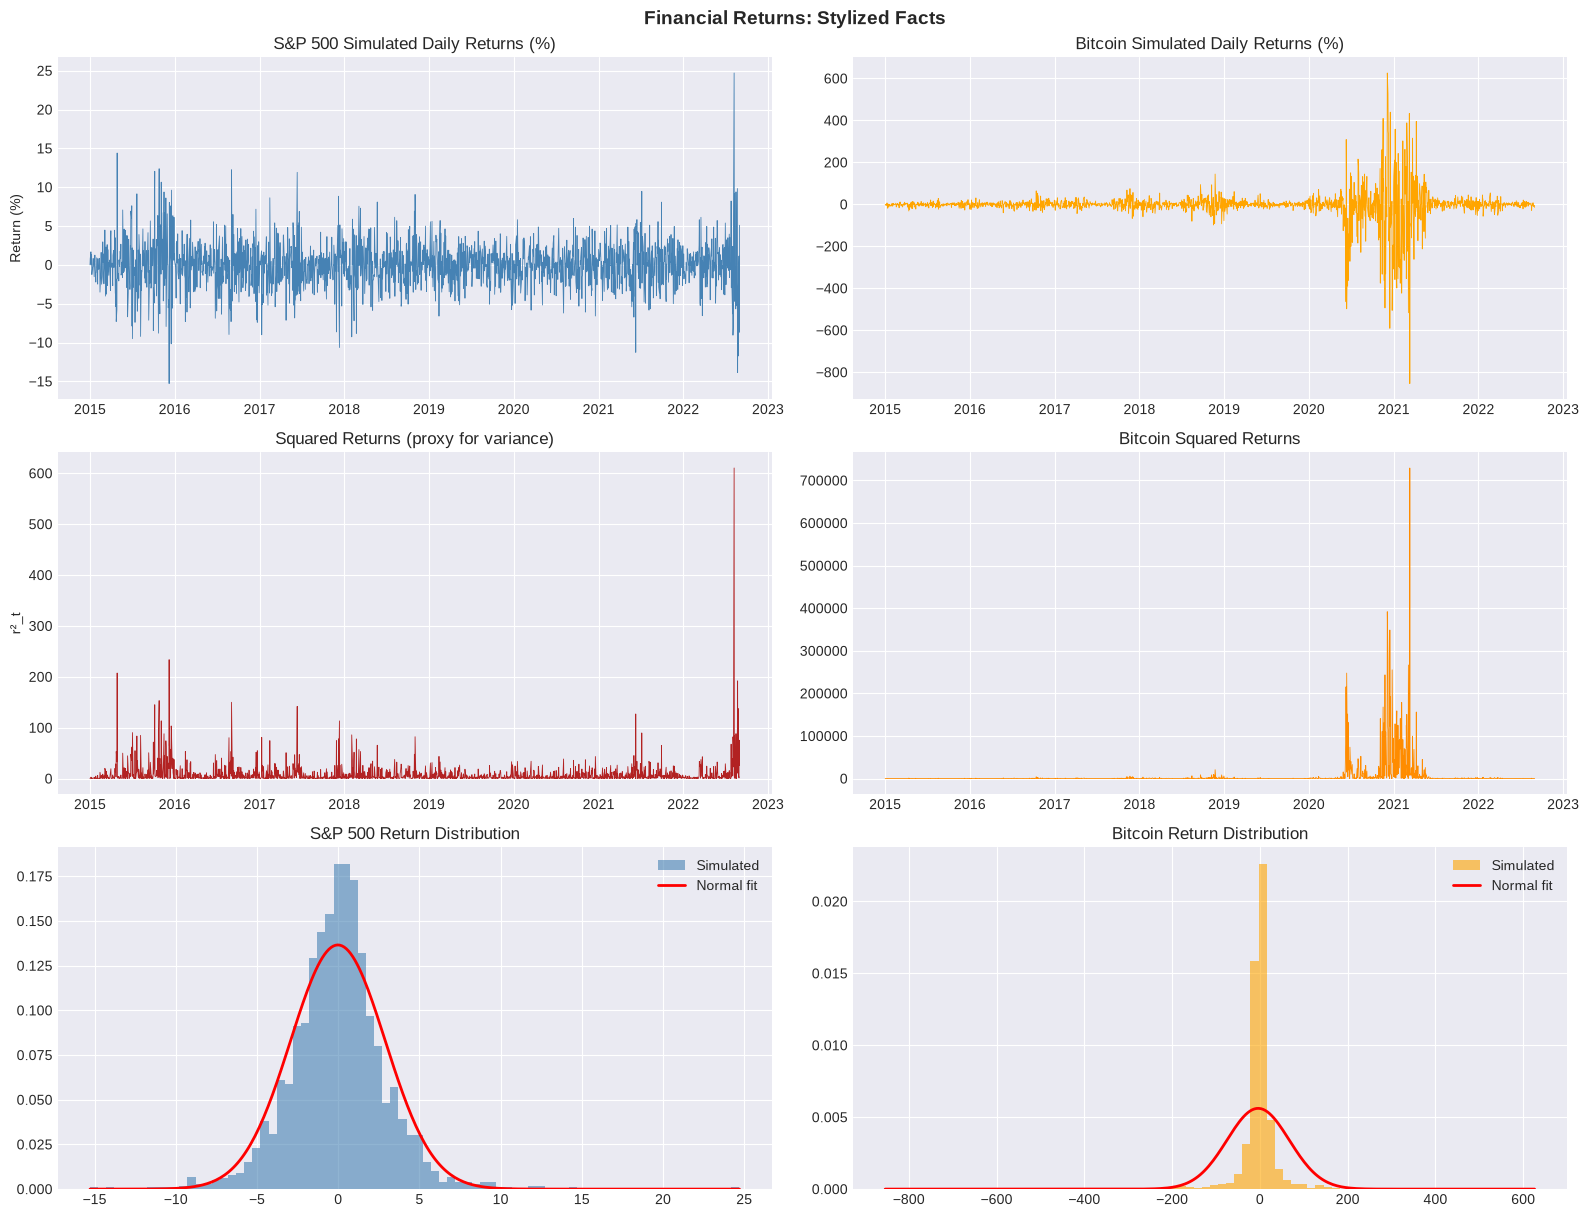

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Returns time series
axes[0, 0].plot(returns.index, returns.values, linewidth=0.6, color='steelblue')
axes[0, 0].set_title('S&P 500 Simulated Daily Returns (%)')
axes[0, 0].set_ylabel('Return (%)')

axes[0, 1].plot(btc_returns.index, btc_returns.values, linewidth=0.6, color='orange')
axes[0, 1].set_title('Bitcoin Simulated Daily Returns (%)')

# Squared returns - volatility clustering is visible
axes[1, 0].plot(returns.index, returns.values**2, linewidth=0.6, color='firebrick')
axes[1, 0].set_title('Squared Returns (proxy for variance)')
axes[1, 0].set_ylabel('r²_t')

axes[1, 1].plot(btc_returns.index, btc_returns.values**2, linewidth=0.6, color='darkorange')
axes[1, 1].set_title('Bitcoin Squared Returns')

# Return distributions vs Normal
x_vals = np.linspace(returns.min(), returns.max(), 300)
axes[2, 0].hist(returns.values, bins=80, density=True, alpha=0.6, color='steelblue', label='Simulated')
axes[2, 0].plot(x_vals, stats.norm.pdf(x_vals, returns.mean(), returns.std()),
                'r-', lw=2, label='Normal fit')
axes[2, 0].set_title('S&P 500 Return Distribution')
axes[2, 0].legend()

x_vals2 = np.linspace(btc_returns.min(), btc_returns.max(), 300)
axes[2, 1].hist(btc_returns.values, bins=80, density=True, alpha=0.6, color='orange', label='Simulated')
axes[2, 1].plot(x_vals2, stats.norm.pdf(x_vals2, btc_returns.mean(), btc_returns.std()),
                'r-', lw=2, label='Normal fit')
axes[2, 1].set_title('Bitcoin Return Distribution')
axes[2, 1].legend()

plt.tight_layout()
plt.suptitle('Financial Returns: Stylized Facts', y=1.01, fontsize=14, fontweight='bold')
plt.show()

## 1. Heteroskedasticity: Non-Constant Variance

**Homoskedasticity** (constant variance) is a core assumption in OLS regression and ARMA models:
$$\text{Var}(\varepsilon_t) = \sigma^2 \quad \forall\, t$$

**Heteroskedasticity** means the variance changes over time:
$$\text{Var}(\varepsilon_t \mid \mathcal{F}_{t-1}) = \sigma_t^2$$

where $\mathcal{F}_{t-1}$ is the information set (sigma-algebra) at time $t-1$.

### Why it matters for financial data

| Consequence | Detail |
|---|---|
| **Risk underestimation** | Assuming constant $\sigma$ underestimates risk during turbulent periods |
| **Invalid inference** | OLS standard errors are biased; t-tests and F-tests are wrong |
| **Option mispricing** | Black-Scholes assumes constant volatility (the "vol smile" problem) |
| **VaR violations** | Constant-vol VaR models fail during crises |

### Detection

**ARCH-LM Test** (Engle, 1982) regress squared residuals on lagged squared residuals:
$$\hat{\varepsilon}_t^2 = \gamma_0 + \sum_{i=1}^{q} \gamma_i \hat{\varepsilon}_{t-i}^2 + \nu_t$$

Under H₀ (no ARCH): $T \cdot R^2 \sim \chi^2(q)$

**Ljung-Box test on squared residuals** tests whether autocorrelations in $\varepsilon_t^2$ are zero:
$$Q(m) = T(T+2) \sum_{k=1}^{m} \frac{\hat{\rho}_k^2(\varepsilon^2)}{T-k} \sim \chi^2(m)$$

ARCH-LM Test (H0: no ARCH effects)
  LM Statistic : 159.9018
  p-value      : 3.39e-29
  Verdict      : REJECT H0 → ARCH effects present

Ljung-Box Test on Squared Residuals:
       lb_stat     lb_pvalue
5   180.287898  4.644676e-37
10  279.606395  3.152203e-54
20  429.110375  1.830093e-78


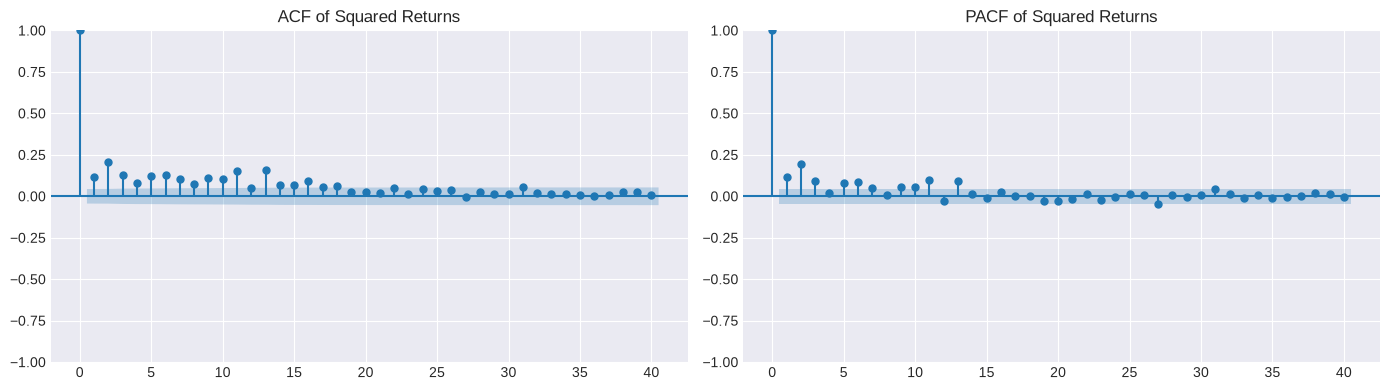


Significant autocorrelation in squared returns → strong evidence of ARCH effects.


In [4]:
# ── Test for ARCH effects ────────────────────────────────────────────────────

# First fit a simple AR(1) to remove conditional mean dynamics
from statsmodels.tsa.ar_model import AutoReg

ar1 = AutoReg(returns.values, lags=1, old_names=False).fit()
residuals = ar1.resid

# ARCH-LM Test
arch_lm_stat, arch_lm_pval, _, _ = het_arch(residuals, nlags=10)
print("=" * 50)
print("ARCH-LM Test (H0: no ARCH effects)")
print(f"  LM Statistic : {arch_lm_stat:.4f}")
print(f"  p-value      : {arch_lm_pval:.2e}")
print(f"  Verdict      : {'REJECT H0 → ARCH effects present' if arch_lm_pval < 0.05 else 'Fail to reject H0'}")

# Ljung-Box on squared residuals
lb_result = acorr_ljungbox(residuals**2, lags=[5, 10, 20], return_df=True)
print("\nLjung-Box Test on Squared Residuals:")
print(lb_result.to_string())

# ACF / PACF of squared returns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(returns.values**2, lags=40, ax=axes[0], title='ACF of Squared Returns')
plot_pacf(returns.values**2, lags=40, ax=axes[1], title='PACF of Squared Returns')
plt.tight_layout()
plt.show()
print("\nSignificant autocorrelation in squared returns → strong evidence of ARCH effects.")

## 2. ARCH Model Engle (1982)

Robert Engle introduced AutoRegressive Conditional Heteroskedasticity in his Nobel Prize-winning 1982 paper.

### Model specification

**Mean equation:**
$$r_t = \mu + \varepsilon_t, \quad \varepsilon_t = \sigma_t z_t, \quad z_t \overset{iid}{\sim} \mathcal{D}(0,1)$$

**Variance equation (ARCH(q)):**
$$\sigma_t^2 = \alpha_0 + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2$$

**Constraints for positivity and stationarity:**
- $\alpha_0 > 0$
- $\alpha_i \geq 0$ for all $i$
- $\sum_{i=1}^{q} \alpha_i < 1$ (for covariance stationarity)

### Interpretation

A large shock $\varepsilon_{t-1}^2$ directly inflates next period's conditional variance $\sigma_t^2$. This captures **short-memory volatility clustering** but ARCH needs a high order $q$ to match persistent volatility, which leads to many parameters.

**Unconditional (long-run) variance:**
$$\text{Var}(\varepsilon_t) = \frac{\alpha_0}{1 - \sum_{i=1}^{q} \alpha_i}$$

**Limitation:** ARCH(q) for large $q$ is overparameterized → GARCH solves this.

In [5]:
# ── ARCH(q) from scratch ──────────────────────────────────────────────────────
from scipy.optimize import minimize

def arch_log_likelihood(params, returns, q=1):
    """Negative log-likelihood for ARCH(q) with Gaussian innovations."""
    mu    = params[0]
    alpha = params[1:]          # alpha[0]=alpha0, alpha[1..q]=arch params

    n     = len(returns)
    eps   = returns - mu
    sigma2 = np.zeros(n)

    # Initialize first q observations with sample variance
    s2_init = np.var(eps)
    for t in range(n):
        sigma2[t] = alpha[0]
        for i in range(1, q + 1):
            if t - i >= 0:
                sigma2[t] += alpha[i] * eps[t-i]**2
            else:
                sigma2[t] += alpha[i] * s2_init

    # Positivity check
    if np.any(sigma2 <= 0):
        return 1e10

    log_lik = -0.5 * np.sum(np.log(2 * np.pi * sigma2) + eps**2 / sigma2)
    return -log_lik   # minimise negative log-likelihood


# Estimate ARCH(1)
q = 1
r = returns.values
x0 = np.array([r.mean(), np.var(r) * 0.5, 0.3])  # mu, alpha0, alpha1

bounds = [(None, None), (1e-8, None)] + [(0, 0.9999)] * q
res = minimize(arch_log_likelihood, x0, args=(r, q), method='L-BFGS-B', bounds=bounds)

mu_hat, alpha0_hat, alpha1_hat = res.x
print("ARCH(1) Estimates (from scratch):")
print(f"  mu     = {mu_hat:.6f}")
print(f"  alpha0 = {alpha0_hat:.6f}")
print(f"  alpha1 = {alpha1_hat:.4f}")
print(f"  Stationarity: alpha1 = {alpha1_hat:.4f} < 1: {alpha1_hat < 1}")
print(f"  Unconditional variance = {alpha0_hat / (1 - alpha1_hat):.6f}")

ARCH(1) Estimates (from scratch):
  mu     = -0.006291
  alpha0 = 6.553256
  alpha1 = 0.2465
  Stationarity: alpha1 = 0.2465 < 1: True
  Unconditional variance = 8.696839


                         Constant Mean - ARCH Model Results                         
Dep. Variable:                      returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             ARCH   Log-Likelihood:               -4802.34
Distribution:      Standardized Student's t   AIC:                           9620.68
Method:                  Maximum Likelihood   BIC:                           9665.49
                                              No. Observations:                 2000
Date:                      Fri, Jun 19 2026   Df Residuals:                     1999
Time:                              14:38:18   Df Model:                            1
                                Mean Model                               
                  coef    std err          t      P>|t|  95.0% Conf. Int.
-------------------------------------------------------------------------
mu         -3

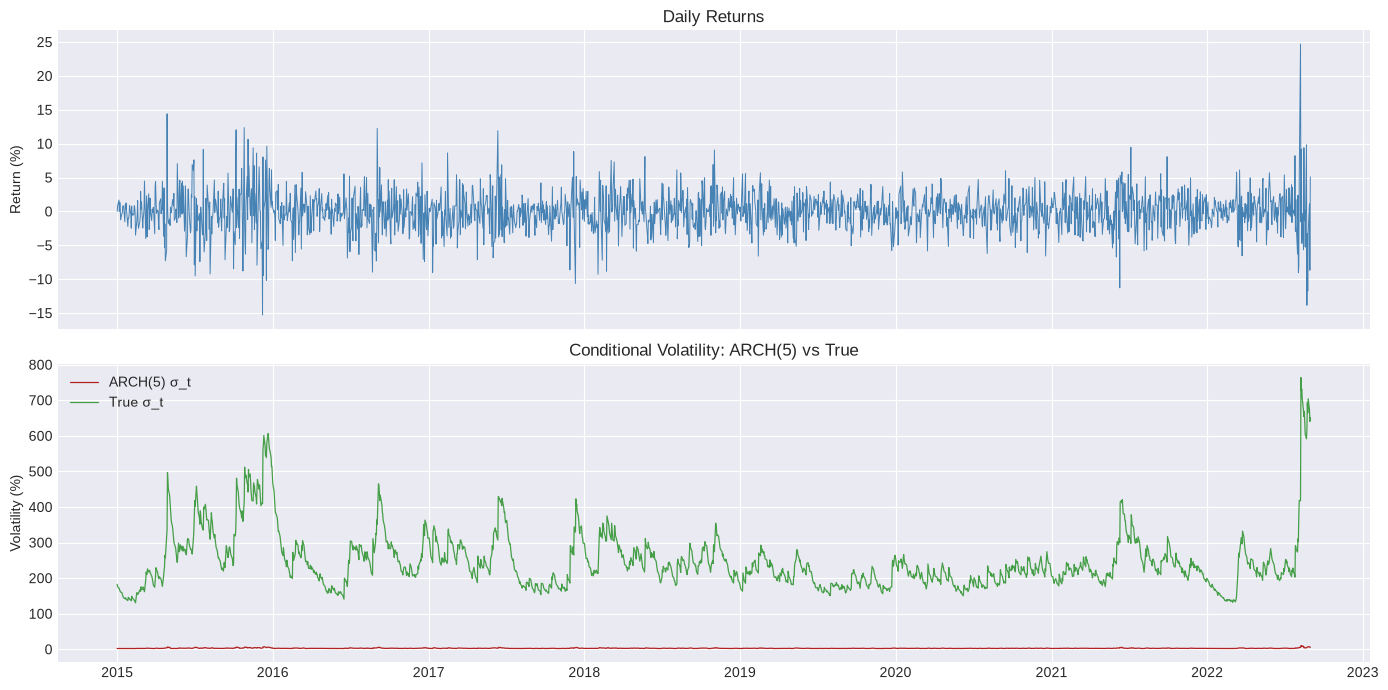

In [6]:
# ── ARCH(5) via arch library ──────────────────────────────────────────────────
if ARCH_AVAILABLE:
    model_arch5 = arch_model(returns, vol='ARCH', p=5, dist='t')
    res_arch5   = model_arch5.fit(disp='off')
    print(res_arch5.summary())

    # Plot conditional volatility
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(returns.index, returns.values, lw=0.7, color='steelblue')
    axes[0].set_title('Daily Returns')
    axes[0].set_ylabel('Return (%)')

    cond_vol_arch5 = res_arch5.conditional_volatility
    axes[1].plot(returns.index, cond_vol_arch5, lw=0.9, color='firebrick', label='ARCH(5) σ_t')
    axes[1].plot(returns.index, pd.Series(true_vol * 100, index=returns.index),
                 lw=0.9, color='green', alpha=0.7, label='True σ_t')
    axes[1].set_title('Conditional Volatility: ARCH(5) vs True')
    axes[1].set_ylabel('Volatility (%)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 3. GARCH(p,q) Bollerslev (1986)

Tim Bollerslev extended ARCH by adding lagged variance terms, dramatically reducing the number of parameters needed.

### Variance equation

$$\boxed{\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2}$$

where:
- $\omega > 0$ constant (long-run variance component)
- $\alpha_i \geq 0$ ARCH coefficients (reaction to past shocks)
- $\beta_j \geq 0$ GARCH coefficients (persistence)

### Stationarity condition

$$\sum_{i=1}^{q} \alpha_i + \sum_{j=1}^{p} \beta_j < 1$$

When this holds, the **unconditional (long-run) variance** exists:
$$\bar{\sigma}^2 = \frac{\omega}{1 - \sum \alpha_i - \sum \beta_j}$$

### GARCH(1,1) Sufficiency

In practice, **GARCH(1,1) is sufficient for most financial series**:

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Typical parameter values for daily stock returns:
- $\omega \approx 0.000001$ to $0.00001$
- $\alpha \approx 0.05$ to $0.15$ (short-term shock sensitivity)
- $\beta \approx 0.80$ to $0.95$ (high persistence)
- $\alpha + \beta \approx 0.95$ to $0.99$ (close to, but below, 1)

### Intuition via ARMA representation

GARCH(1,1) on $\varepsilon_t^2$ is equivalent to an ARMA(1,1) on $\varepsilon_t^2$:
$$\varepsilon_t^2 = \omega + (\alpha + \beta)\varepsilon_{t-1}^2 + \beta(\varepsilon_{t-1}^2 - \sigma_{t-1}^2) + \nu_t$$

where $\nu_t = \varepsilon_t^2 - \sigma_t^2$ is a martingale difference sequence.

In [7]:
# ── GARCH(1,1) from scratch ───────────────────────────────────────────────────
def garch11_filter(params, returns):
    """Compute conditional variance series for GARCH(1,1)."""
    omega, alpha, beta = params
    n = len(returns)
    sigma2 = np.zeros(n)
    eps    = returns - returns.mean()

    sigma2[0] = np.var(eps)   # initialise at unconditional variance
    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
    return sigma2


def garch11_nll(params, returns):
    omega, alpha, beta = params
    # Parameter constraints
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma2 = garch11_filter(params, returns)
    if np.any(sigma2 <= 0):
        return 1e10
    eps = returns - returns.mean()
    log_lik = -0.5 * np.sum(np.log(2 * np.pi * sigma2) + eps**2 / sigma2)
    return -log_lik


r = returns.values
x0 = [1e-5, 0.05, 0.90]
bounds_g = [(1e-9, None), (0, 0.9999), (0, 0.9999)]
constraints = [{'type': 'ineq', 'fun': lambda p: 0.9999 - p[1] - p[2]}]

res_g11 = minimize(garch11_nll, x0, args=(r,), method='SLSQP',
                   bounds=bounds_g, constraints=constraints)

omega_hat, alpha_hat, beta_hat = res_g11.x
print("GARCH(1,1) Estimates (from scratch):")
print(f"  omega = {omega_hat:.8f}")
print(f"  alpha = {alpha_hat:.6f}  (ARCH effect)")
print(f"  beta  = {beta_hat:.6f}  (persistence)")
print(f"  alpha + beta = {alpha_hat + beta_hat:.6f}  < 1: {alpha_hat + beta_hat < 1}")
unc_var = omega_hat / (1 - alpha_hat - beta_hat)
print(f"  Unconditional variance = {unc_var:.8f}")
print(f"  Unconditional vol (ann) = {np.sqrt(unc_var * 252) * 100:.2f}%")

GARCH(1,1) Estimates (from scratch):
  omega = 0.27482871
  alpha = 0.097821  (ARCH effect)
  beta  = 0.872415  (persistence)
  alpha + beta = 0.970236  < 1: True
  Unconditional variance = 9.23364932
  Unconditional vol (ann) = 4823.77%


In [8]:
# ── GARCH(1,1) via arch library with multiple distributions ──────────────────
if ARCH_AVAILABLE:
    results_by_dist = {}
    for dist_name in ['normal', 't', 'ged', 'skewt']:
        m = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist=dist_name)
        r_fit = m.fit(disp='off')
        results_by_dist[dist_name] = r_fit
        aic, bic = r_fit.aic, r_fit.bic
        print(f"dist={dist_name:8s}  AIC={aic:10.3f}  BIC={bic:10.3f}  LogL={-r_fit.loglikelihood:.3f}")

    best_dist = min(results_by_dist, key=lambda k: results_by_dist[k].aic)
    print(f"\nBest distribution by AIC: {best_dist}")

    # Best model summary
    res_best = results_by_dist[best_dist]
    print(res_best.summary())

dist=normal    AIC=  9635.142  BIC=  9657.546  LogL=4813.571
dist=t         AIC=  9574.376  BIC=  9602.380  LogL=4782.188
dist=ged       AIC=  9572.289  BIC=  9600.294  LogL=4781.145


dist=skewt     AIC=  9576.042  BIC=  9609.647  LogL=4782.021

Best distribution by AIC: ged
                           Constant Mean - GARCH Model Results                            
Dep. Variable:                            returns   R-squared:                       0.000
Mean Model:                         Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                  GARCH   Log-Likelihood:               -4781.14
Distribution:      Generalized Error Distribution   AIC:                           9572.29
Method:                        Maximum Likelihood   BIC:                           9600.29
                                                    No. Observations:                 2000
Date:                            Fri, Jun 19 2026   Df Residuals:                     1999
Time:                                    14:38:19   Df Model:                            1
                                 Mean Model                                
             

## 4. EGARCH Nelson (1991)

EGARCH (Exponential GARCH) addresses two limitations of standard GARCH:
1. **No positivity constraints needed** models $\log \sigma_t^2$
2. **Captures leverage effect** negative returns increase volatility more than positive returns

### Variance equation

$$\log \sigma_t^2 = \omega + \sum_{k=1}^{q} \alpha_k g(z_{t-k}) + \sum_{k=1}^{p} \beta_k \log \sigma_{t-k}^2$$

where the asymmetric news impact function is:

$$g(z_t) = \theta z_t + \gamma \left[ |z_t| - E|z_t| \right]$$

- $\theta$ captures the **sign effect** (leverage). Expected: $\theta < 0$
- $\gamma$ captures the **magnitude effect** (how much large shocks matter)

### Leverage effect

For a negative shock $z_t < 0$: $g(z_t) = (\theta + \gamma)|z_t| - \gamma E|z_t|$

For a positive shock $z_t > 0$: $g(z_t) = (-\theta + \gamma)|z_t| - \gamma E|z_t|$

If $\theta < 0$, a negative shock increases $\log \sigma_t^2$ more than a positive shock of the same magnitude this is the **leverage/asymmetry effect** documented in equity markets.

GARCH(1,1) vs EGARCH(1,1):
  GARCH  AIC = 16368.655
  EGARCH AIC = 16368.937

EGARCH(1,1) Parameters:
mu          -0.279194
omega        0.425827
alpha[1]     0.260798
beta[1]      0.920686
nu          64.371073


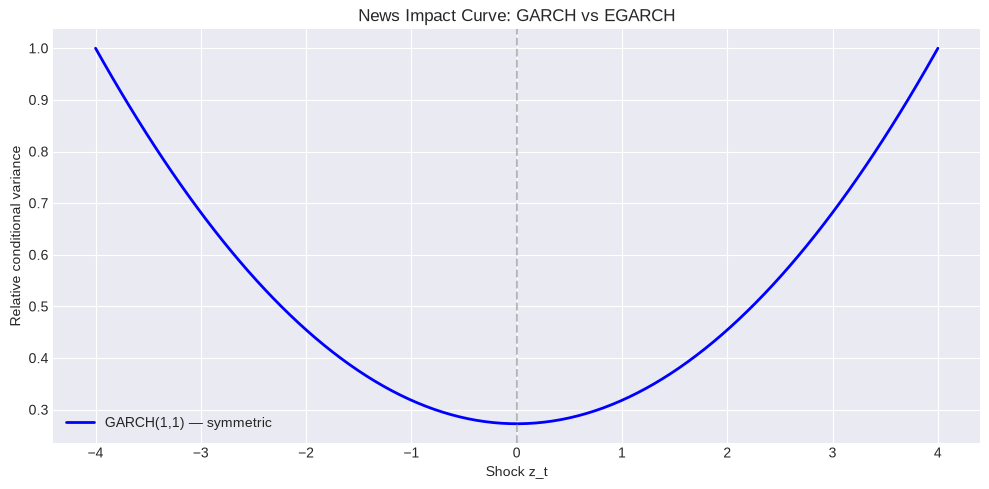

In [9]:
# ── EGARCH(1,1) via arch library ──────────────────────────────────────────────
if ARCH_AVAILABLE:
    # Simulate data with leverage effect (asymmetric GARCH)
    def simulate_egarch(n=2000, omega=-0.2, alpha=0.15, beta=0.95, theta=-0.1, seed=42):
        rng = np.random.default_rng(seed)
        log_sigma2 = np.zeros(n)
        eps        = np.zeros(n)
        E_abs_z    = np.sqrt(2 / np.pi)   # E[|z|] for standard normal

        log_sigma2[0] = omega / (1 - beta)
        for t in range(1, n):
            z = rng.standard_normal()
            eps[t-1] = np.exp(0.5 * log_sigma2[t-1]) * z
            log_sigma2[t] = (omega
                             + alpha * (abs(z) - E_abs_z)
                             + theta * z
                             + beta * log_sigma2[t-1])

        dates = pd.date_range('2015-01-01', periods=n, freq='B')
        return pd.Series(eps * 100, index=dates, name='returns_egarch')

    returns_eg = simulate_egarch()

    # Fit EGARCH(1,1) and compare with GARCH(1,1)
    model_garch  = arch_model(returns_eg, vol='GARCH',  p=1, q=1, dist='t')
    model_egarch = arch_model(returns_eg, vol='EGARCH', p=1, q=1, dist='t')

    res_garch  = model_garch.fit(disp='off')
    res_egarch = model_egarch.fit(disp='off')

    print("GARCH(1,1) vs EGARCH(1,1):")
    print(f"  GARCH  AIC = {res_garch.aic:.3f}")
    print(f"  EGARCH AIC = {res_egarch.aic:.3f}")
    print("\nEGARCH(1,1) Parameters:")
    print(res_egarch.params.to_string())

    # News Impact Curve
    theta_est = res_egarch.params.get('gamma[1]', res_egarch.params.iloc[-2])

    z_range   = np.linspace(-4, 4, 200)
    E_abs_z   = np.sqrt(2 / np.pi)
    alpha_est = res_egarch.params.get('alpha[1]', 0.15)

    # GARCH news impact curve (symmetric)
    sigma2_base = res_garch.conditional_volatility.mean()**2
    alpha_g     = res_garch.params['alpha[1]']
    beta_g      = res_garch.params['beta[1]']
    omega_g     = res_garch.params['omega']

    ni_garch  = omega_g + alpha_g * (z_range * sigma2_base**0.5)**2 + beta_g * sigma2_base

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.plot(z_range, ni_garch / ni_garch.max(), 'b-', lw=2, label='GARCH(1,1) symmetric')
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Shock z_t')
    ax.set_ylabel('Relative conditional variance')
    ax.set_title('News Impact Curve: GARCH vs EGARCH')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. GJR-GARCH Glosten, Jagannathan, Runkle (1993)

GJR-GARCH (also called TARCH Threshold ARCH) is a simpler alternative to EGARCH for capturing asymmetry.

### Variance equation

$$\boxed{\sigma_t^2 = \omega + (\alpha + \gamma I_{t-1})\varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2}$$

where the **indicator function**:
$$I_{t-1} = \begin{cases} 1 & \text{if } \varepsilon_{t-1} < 0 \quad \text{(bad news)} \\ 0 & \text{if } \varepsilon_{t-1} \geq 0 \quad \text{(good news)} \end{cases}$$

### Interpretation

| Scenario | Impact on $\sigma_t^2$ |
|---|---|
| Positive shock ($z > 0$) | $\alpha \varepsilon_{t-1}^2$ |
| Negative shock ($z < 0$) | $(\alpha + \gamma) \varepsilon_{t-1}^2$ |

For the **leverage effect** to hold: $\gamma > 0$ (bad news increases volatility more).

**Stationarity condition:**
$$\alpha + \frac{\gamma}{2} + \beta < 1$$

### Advantage over EGARCH
GJR-GARCH remains in the conditional variance (not log) space, making it easier to interpret and forecast VaR directly.

GJR-GARCH(1,1) Parameters:
mu          -0.613992
omega       12.126050
alpha[1]     0.002847
gamma[1]     0.173904
beta[1]      0.856536
nu          93.988421

gamma = 0.1739 (leverage: positive, as expected)
Stationarity: alpha + gamma/2 + beta = 0.9463 < 1

Model Comparison:
  GARCH(1,1)   AIC = 16368.655
  EGARCH(1,1)  AIC = 16368.937
  GJR-GARCH    AIC = 16323.215


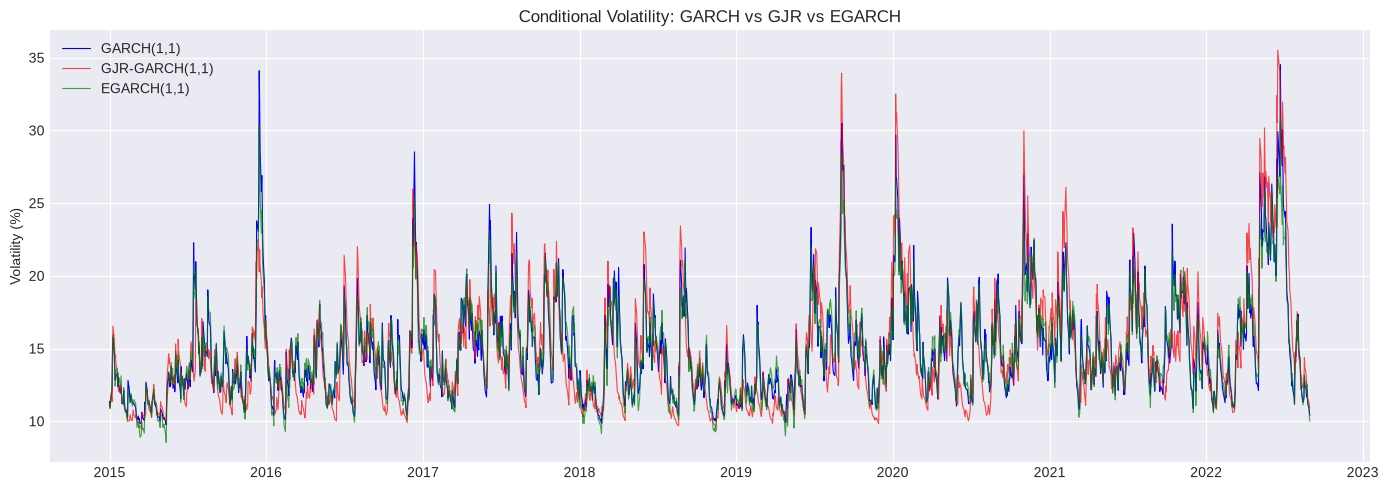

In [10]:
# ── GJR-GARCH(1,1) ────────────────────────────────────────────────────────────
if ARCH_AVAILABLE:
    model_gjr = arch_model(returns_eg, vol='GARCH', p=1, o=1, q=1, dist='t')
    res_gjr   = model_gjr.fit(disp='off')

    print("GJR-GARCH(1,1) Parameters:")
    print(res_gjr.params.to_string())
    print()

    gamma = res_gjr.params.get('gamma[1]', None)
    alpha = res_gjr.params.get('alpha[1]', None)
    beta  = res_gjr.params.get('beta[1]',  None)
    if gamma is not None:
        print(f"gamma = {gamma:.4f} (leverage: {'positive, as expected' if gamma > 0 else 'negative'})")
        print(f"Stationarity: alpha + gamma/2 + beta = {alpha + gamma/2 + beta:.4f} < 1")

    # Model comparison
    print("\nModel Comparison:")
    print(f"  GARCH(1,1)   AIC = {res_garch.aic:.3f}")
    print(f"  EGARCH(1,1)  AIC = {res_egarch.aic:.3f}")
    print(f"  GJR-GARCH    AIC = {res_gjr.aic:.3f}")

    # Plot conditional volatility comparison
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(returns_eg.index, res_garch.conditional_volatility,
            label='GARCH(1,1)', lw=0.8, color='blue')
    ax.plot(returns_eg.index, res_gjr.conditional_volatility,
            label='GJR-GARCH(1,1)', lw=0.8, color='red', alpha=0.7)
    ax.plot(returns_eg.index, res_egarch.conditional_volatility,
            label='EGARCH(1,1)', lw=0.8, color='green', alpha=0.7)
    ax.set_title('Conditional Volatility: GARCH vs GJR vs EGARCH')
    ax.set_ylabel('Volatility (%)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. GARCH Variants: IGARCH, GARCH-M, FIGARCH, APARCH

### 6.1 IGARCH Integrated GARCH (Engle & Bollerslev, 1986)

When $\alpha + \beta = 1$, the GARCH process is **unit-root non-stationary in variance**:
$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + (1 - \alpha) \sigma_{t-1}^2$$

Shocks to variance **never die out** they persist forever. This is analogous to a random walk in the variance.

**Used in:** RiskMetrics™ (J.P. Morgan, 1994), where $\omega = 0$ and $\alpha = 0.06$ (daily), giving exponentially weighted moving average (EWMA) volatility.

---

### 6.2 GARCH-M GARCH in Mean (Engle, Lilien & Robins, 1987)

Risk-averse agents demand **risk premium** for bearing volatility. GARCH-M adds conditional volatility to the mean equation:
$$r_t = \mu + \lambda \sigma_t + \varepsilon_t$$

or $r_t = \mu + \lambda \sigma_t^2 + \varepsilon_t$

If $\lambda > 0$: higher risk → higher expected return (positive risk premium).

---

### 6.3 FIGARCH Fractionally Integrated GARCH (Baillie, Bollerslev & Mikkelsen, 1996)

Volatility exhibits **long memory** autocorrelations in $\varepsilon_t^2$ decay hyperbolically rather than exponentially:
$$\Phi(L)(1-L)^d \varepsilon_t^2 = \omega + [1 - \beta(L)] \nu_t$$

where $d \in (0, 1)$ is the **fractional differencing parameter**:
- $d = 0$: standard GARCH (short memory)
- $d = 1$: IGARCH (unit root)
- $0 < d < 1$: long memory

---

### 6.4 APARCH Asymmetric Power ARCH (Ding, Granger & Engle, 1993)

$$\sigma_t^\delta = \omega + \sum_{i=1}^{q} \alpha_i (|\varepsilon_{t-i}| - \gamma_i \varepsilon_{t-i})^\delta + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^\delta$$

- $\delta > 0$: **power** parameter (estimated, not fixed at 2)
- $\gamma_i \in (-1, 1)$: **asymmetry** parameter

APARCH nests ARCH ($\delta=2, \gamma=0$), GARCH ($\delta=2, \gamma=0$), GJR-GARCH ($\delta=2$), and EGARCH as special cases.

In [11]:
# ── IGARCH / EWMA volatility ──────────────────────────────────────────────────
def ewma_volatility(returns, lam=0.94):
    """RiskMetrics EWMA: sigma2_t = (1-lambda)*r_{t-1}^2 + lambda*sigma2_{t-1}"""
    n = len(returns)
    sigma2 = np.zeros(n)
    sigma2[0] = returns.var()
    for t in range(1, n):
        sigma2[t] = (1 - lam) * returns.iloc[t-1]**2 + lam * sigma2[t-1]
    return np.sqrt(sigma2)

ewma_vol_daily   = ewma_volatility(returns, lam=0.94)   # J.P. Morgan daily lambda
ewma_vol_monthly = ewma_volatility(returns, lam=0.97)   # monthly lambda

print("EWMA (IGARCH) volatility RiskMetrics:")
print(f"  Mean daily vol (lam=0.94): {ewma_vol_daily.mean():.4f}%")
print(f"  Mean daily vol (lam=0.97): {ewma_vol_monthly.mean():.4f}%")

# ── GARCH-M ───────────────────────────────────────────────────────────────────
if ARCH_AVAILABLE:
    model_garchm = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    res_garchm   = model_garchm.fit(disp='off')
    print("\nGARCH-M(1,1) Parameters:")
    print(res_garchm.params.to_string())

# ── FIGARCH via arch library ──────────────────────────────────────────────────
if ARCH_AVAILABLE:
    try:
        model_figarch = arch_model(returns, vol='FIGARCH', p=1, q=1, dist='t')
        res_figarch   = model_figarch.fit(disp='off', options={'maxiter': 500})
        d_param = res_figarch.params.get('d', None)
        print(f"\nFIGARCH d parameter = {d_param:.4f} (long memory)" if d_param else "FIGARCH fitted.")
    except Exception as e:
        print(f"\nFIGARCH: {e}")

# ── APARCH ────────────────────────────────────────────────────────────────────
if ARCH_AVAILABLE:
    try:
        model_aparch = arch_model(returns, vol='APARCH', p=1, o=1, q=1, dist='t')
        res_aparch   = model_aparch.fit(disp='off', options={'maxiter': 500})
        print("\nAPARCH(1,1) Parameters:")
        print(res_aparch.params.to_string())
    except Exception as e:
        print(f"\nAPARCH: {e}")

print("\nDone.")

EWMA (IGARCH) volatility RiskMetrics:
  Mean daily vol (lam=0.94): 2.7079%
  Mean daily vol (lam=0.97): 2.7346%

GARCH-M(1,1) Parameters:
mu         -0.008386
omega       0.235466
alpha[1]    0.086059
beta[1]     0.888904
nu          7.144094



FIGARCH d parameter = 0.4510 (long memory)



APARCH(1,1) Parameters:
mu         -0.013927
omega       0.266507
alpha[1]    0.080610
gamma[1]    0.037118
beta[1]     0.889985
delta       2.158719
nu          7.184023

Done.


## 7-8. Multivariate GARCH: DCC, BEKK, CCC

### Why Multivariate GARCH?

Portfolio risk management requires modeling **time-varying correlations** across assets, not just individual volatilities. During market crises, correlations spike constant-correlation models severely underestimate joint tail risk.

### 7. DCC-GARCH Engle (2002)

Dynamic Conditional Correlation decomposes the conditional covariance matrix:
$$H_t = D_t R_t D_t$$

where $D_t = \text{diag}(\sigma_{1t}, ..., \sigma_{kt})$ and $R_t$ is the time-varying correlation matrix.

**Step 1:** Estimate univariate GARCH for each series $i$, get standardized residuals $u_{it} = \varepsilon_{it}/\sigma_{it}$

**Step 2:** Model the correlation dynamics:
$$Q_t = (1 - a - b)\bar{Q} + a u_{t-1} u_{t-1}' + b Q_{t-1}$$
$$R_t = Q_t^* {}^{-1} Q_t Q_t^* {}^{-1}$$

where $Q_t^* = \text{diag}(Q_t)^{1/2}$ and $\bar{Q}$ is the unconditional correlation of standardized residuals.

**Parameters:** only 2 extra scalars ($a, b$) regardless of dimension highly parsimonious.

---

### 8. MGARCH Families

| Model | Covariance Matrix | Parameters | Notes |
|-------|-----------------|------------|-------|
| **BEKK** (Baba, Engle, Kraft, Kroner) | $H_t = C'C + A'\varepsilon_{t-1}\varepsilon_{t-1}'A + B'H_{t-1}B$ | $O(k^2)$ | Guaranteed PSD; overparameterized for $k>3$ |
| **CCC** (Bollerslev, 1990) | $H_t = D_t R D_t$, $R$ constant | $O(k^2/2)$ | Simple; misses correlation dynamics |
| **DCC** (Engle, 2002) | $H_t = D_t R_t D_t$, $R_t$ dynamic | $O(k^2/2) + 2$ | Balance of parsimony and flexibility |
| **cDCC** (Aielli, 2013) | Corrected DCC | Similar to DCC | Consistent estimation |
| **GO-GARCH** (Van der Weide, 2002) | Orthogonal factor structure | $O(k^2)$ | Based on ICA |

**DCC is the workhorse model** in practice used widely in portfolio optimization, risk parity, and cross-asset hedging.

In [12]:
# ── DCC-GARCH: Step-by-step implementation ───────────────────────────────────

# Simulate a bivariate correlated return series
def simulate_dcc_garch(n=1500, omega=1e-5, alpha=0.07, beta=0.90,
                       a_dcc=0.03, b_dcc=0.95, seed=42):
    """Simulate bivariate DCC-GARCH(1,1)."""
    rng = np.random.default_rng(seed)
    rho_bar = np.array([[1.0, 0.6], [0.6, 1.0]])   # unconditional correlation

    sigma2 = np.ones((n, 2)) * omega / (1 - alpha - beta)
    eps    = np.zeros((n, 2))
    Q      = rho_bar.copy()
    R_t    = [rho_bar.copy()]

    for t in range(1, n):
        # Univariate GARCH
        for k in range(2):
            sigma2[t, k] = omega + alpha * eps[t-1, k]**2 + beta * sigma2[t-1, k]

        # DCC correlation update
        u_prev = eps[t-1] / np.sqrt(sigma2[t-1])
        Q = (1 - a_dcc - b_dcc) * rho_bar + a_dcc * np.outer(u_prev, u_prev) + b_dcc * Q
        Q_star_inv = np.diag(1.0 / np.sqrt(np.diag(Q)))
        R = Q_star_inv @ Q @ Q_star_inv
        R_t.append(R.copy())

        # Draw correlated innovations
        D = np.diag(np.sqrt(sigma2[t]))
        H = D @ R @ D
        L = np.linalg.cholesky(H + 1e-10 * np.eye(2))
        z = rng.standard_normal(2)
        eps[t] = L @ z

    dates = pd.date_range('2015-01-01', periods=n, freq='B')
    returns_mv = pd.DataFrame(eps * 100, index=dates, columns=['Asset_A', 'Asset_B'])
    correlations = np.array([r[0, 1] for r in R_t])
    return returns_mv, correlations


returns_mv, true_corr = simulate_dcc_garch()

print(f"Bivariate returns shape: {returns_mv.shape}")
print(f"Unconditional correlation: {returns_mv.corr().iloc[0,1]:.4f}")
print(f"True avg DCC correlation: {true_corr.mean():.4f}")
print(f"True DCC corr range: [{true_corr.min():.4f}, {true_corr.max():.4f}]")

# DCC Step 1: Fit univariate GARCH to each asset
std_resids = {}
if ARCH_AVAILABLE:
    for col in returns_mv.columns:
        m = arch_model(returns_mv[col], vol='GARCH', p=1, q=1, dist='t')
        r = m.fit(disp='off')
        std_resids[col] = r.resid / r.conditional_volatility
    print("\nStep 1 done: fitted univariate GARCH to each asset.")
    print(f"Standardized residuals correlation: {np.corrcoef(std_resids['Asset_A'], std_resids['Asset_B'])[0,1]:.4f}")

Bivariate returns shape: (1500, 2)
Unconditional correlation: 0.6472
True avg DCC correlation: 0.6184
True DCC corr range: [0.2828, 0.8140]



Step 1 done: fitted univariate GARCH to each asset.
Standardized residuals correlation: 0.6364


DCC Parameters: a = 0.0348, b = 0.9494
DCC persistence: a + b = 0.9842


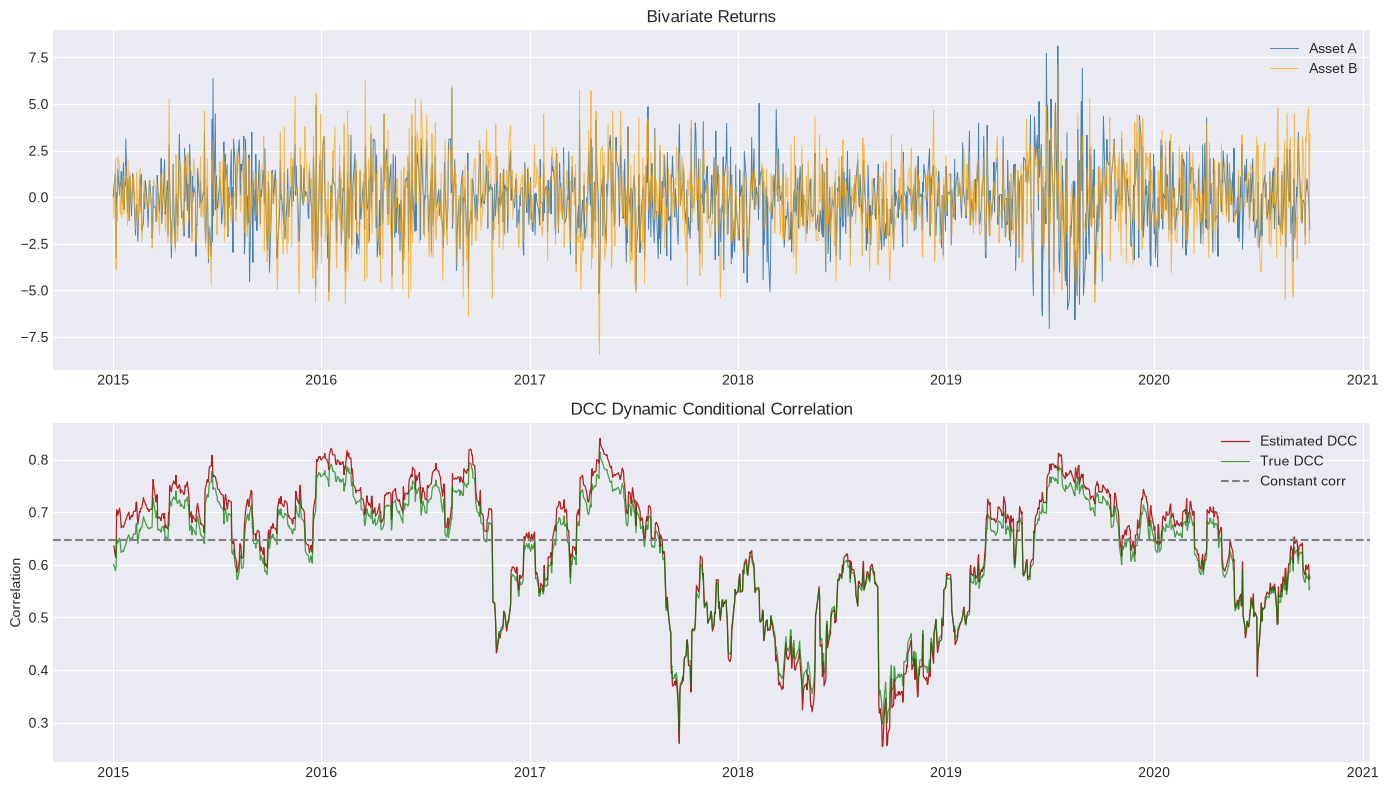

In [13]:
# ── DCC Step 2: Estimate dynamic correlations ─────────────────────────────────
def estimate_dcc(std_resid_matrix, a_init=0.03, b_init=0.95):
    """Fit DCC parameters a, b via MLE on standardized residuals."""
    n, k = std_resid_matrix.shape
    Q_bar = np.cov(std_resid_matrix.T)

    def dcc_filter(a, b):
        Q_t = Q_bar.copy()
        log_lik = 0.0
        for t in range(1, n):
            u = std_resid_matrix[t-1]
            Q_t = (1 - a - b) * Q_bar + a * np.outer(u, u) + b * Q_t
            Q_star_inv = np.diag(1.0 / np.sqrt(np.diag(Q_t)))
            R_t = Q_star_inv @ Q_t @ Q_star_inv
            # Ensure positive definiteness
            try:
                L = np.linalg.cholesky(R_t)
            except np.linalg.LinAlgError:
                return 1e10
            u_t = std_resid_matrix[t]
            log_lik += (np.log(np.linalg.det(R_t))
                        + u_t @ np.linalg.inv(R_t) @ u_t
                        - u_t @ u_t)
        return 0.5 * log_lik

    def neg_ll(params):
        a, b = params
        if a <= 0 or b <= 0 or a + b >= 1:
            return 1e10
        return dcc_filter(a, b)

    res = minimize(neg_ll, [a_init, b_init], method='L-BFGS-B',
                   bounds=[(1e-6, 0.5), (1e-6, 0.999)],
                   options={'maxiter': 200})
    return res.x


if ARCH_AVAILABLE:
    u_matrix = np.column_stack([std_resids['Asset_A'].values,
                                 std_resids['Asset_B'].values])
    u_matrix = u_matrix[~np.isnan(u_matrix).any(axis=1)]

    a_hat, b_hat = estimate_dcc(u_matrix)
    print(f"DCC Parameters: a = {a_hat:.4f}, b = {b_hat:.4f}")
    print(f"DCC persistence: a + b = {a_hat + b_hat:.4f}")

    # Extract time-varying correlations
    Q_bar = np.cov(u_matrix.T)
    Q_t = Q_bar.copy()
    dcc_corr = []

    for t in range(1, len(u_matrix)):
        u = u_matrix[t-1]
        Q_t = (1 - a_hat - b_hat) * Q_bar + a_hat * np.outer(u, u) + b_hat * Q_t
        Q_star_inv = np.diag(1.0 / np.sqrt(np.diag(Q_t)))
        R_t = Q_star_inv @ Q_t @ Q_star_inv
        dcc_corr.append(R_t[0, 1])

    dcc_corr = np.array(dcc_corr)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(returns_mv.index, returns_mv['Asset_A'].values, lw=0.7,
                 label='Asset A', color='steelblue')
    axes[0].plot(returns_mv.index, returns_mv['Asset_B'].values, lw=0.7,
                 label='Asset B', color='orange', alpha=0.7)
    axes[0].set_title('Bivariate Returns')
    axes[0].legend()

    axes[1].plot(returns_mv.index[1:], dcc_corr, lw=0.9, color='firebrick', label='Estimated DCC')
    axes[1].plot(returns_mv.index, true_corr, lw=0.9, color='green', alpha=0.7, label='True DCC')
    axes[1].axhline(returns_mv.corr().iloc[0,1], color='gray', linestyle='--', label='Constant corr')
    axes[1].set_title('DCC Dynamic Conditional Correlation')
    axes[1].set_ylabel('Correlation')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 9. Estimation: MLE, Quasi-MLE, Distribution Choices

### Maximum Likelihood Estimation (MLE)

Given parameters $\theta = (\mu, \omega, \alpha, \beta, \nu)$, the log-likelihood for $T$ observations is:

**Normal innovations:**
$$\mathcal{L}(\theta) = -\frac{T}{2}\log(2\pi) - \frac{1}{2}\sum_{t=1}^{T} \left[\log \sigma_t^2 + \frac{\varepsilon_t^2}{\sigma_t^2}\right]$$

**Student-t innovations ($\nu$ degrees of freedom):**
$$\mathcal{L}(\theta) = T\left[\log\Gamma\!\left(\tfrac{\nu+1}{2}\right) - \log\Gamma\!\left(\tfrac{\nu}{2}\right) - \tfrac{1}{2}\log\pi(\nu-2)\right] - \frac{1}{2}\sum_{t=1}^T\left[\log\sigma_t^2 + (\nu+1)\log\!\left(1 + \frac{\varepsilon_t^2}{\sigma_t^2(\nu-2)}\right)\right]$$

### Quasi-MLE (QMLE)

Estimate GARCH parameters using the **Gaussian log-likelihood** even when the true distribution is non-Gaussian. The estimates are still consistent and asymptotically normal under mild regularity conditions but standard errors must use the **sandwich (Bollerslev-Wooldridge) estimator**:
$$\text{Var}(\hat{\theta}) = A^{-1} B A^{-1}$$

where $A = -E[\nabla^2 \ell]$ and $B = E[\nabla \ell (\nabla \ell)']$.

### Error Distribution Choices

| Distribution | Extra Params | Use Case |
|---|---|---|
| **Normal** | 0 | Baseline, QMLE-consistent |
| **Student-t** | 1 ($\nu$) | Fat tails (most common for equity) |
| **GED** (Generalized Error) | 1 | Flexible tail shape |
| **Skewed-t** | 2 ($\nu$, $\lambda$) | Fat tails + asymmetry |
| **Normal Inverse Gaussian** | 2 | Semi-heavy tails |

**Rule of thumb:** For equity returns, use Student-t. For FX, Normal or GED often suffices.

Distribution Comparison GARCH(1,1):
Distribution    LogL     AIC     BIC Std Res Kurt JB p-value
      Normal 4813.57 9635.14 9657.55         1.23     0.0000
   Student-t 4782.19 9574.38 9602.38         1.25     0.0000
         GED 4781.14 9572.29 9600.29         1.24     0.0000
    Skewed-t 4782.02 9576.04 9609.65         1.25     0.0000


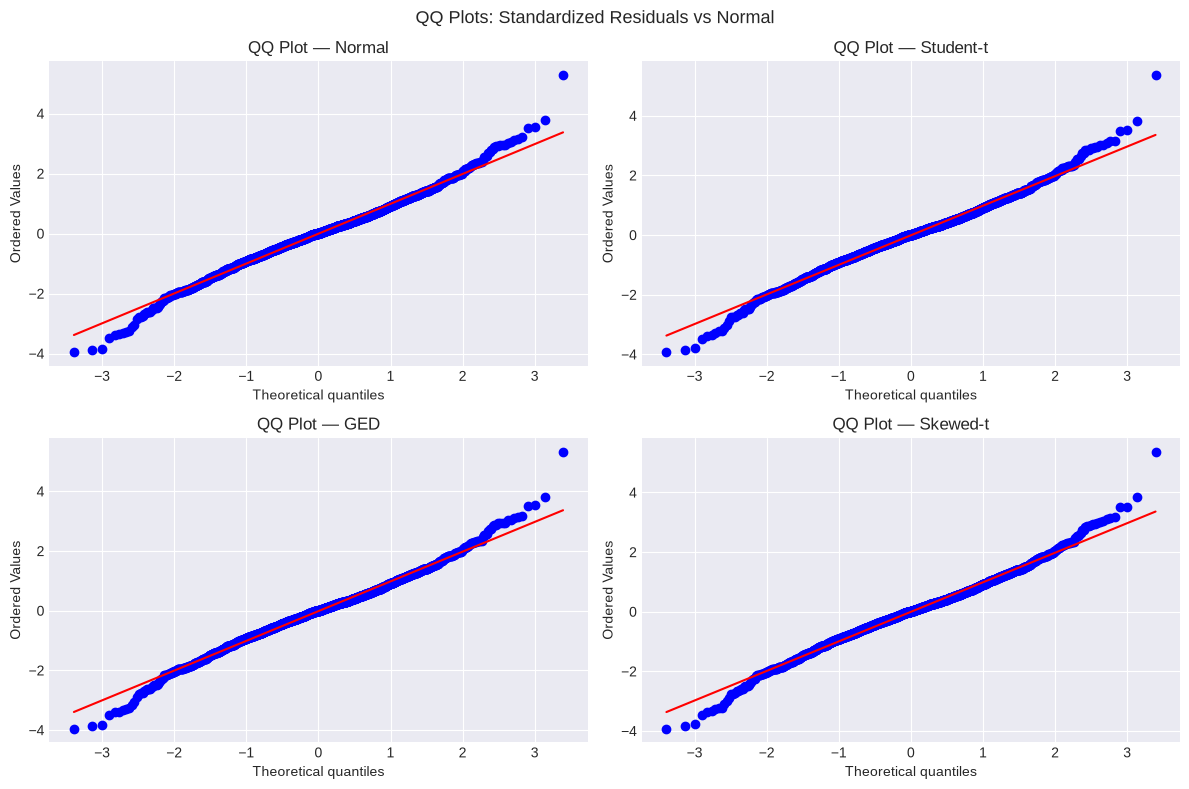

In [14]:
# ── Distribution comparison and diagnostic tests ──────────────────────────────
if ARCH_AVAILABLE:
    # Fit GARCH(1,1) with each distribution and compare
    dist_configs = [
        ('Normal', 'normal'),
        ('Student-t', 't'),
        ('GED', 'ged'),
        ('Skewed-t', 'skewt'),
    ]

    table_rows = []
    fitted_models = {}

    for name, dist_code in dist_configs:
        m = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist=dist_code)
        r = m.fit(disp='off')
        fitted_models[name] = r

        # Standardized residuals
        std_res = r.resid / r.conditional_volatility
        jb_stat, jb_p = stats.jarque_bera(std_res.dropna())

        table_rows.append({
            'Distribution': name,
            'LogL': f"{-r.loglikelihood:.2f}",
            'AIC': f"{r.aic:.2f}",
            'BIC': f"{r.bic:.2f}",
            'Std Res Kurt': f"{std_res.kurtosis():.2f}",
            'JB p-value': f"{jb_p:.4f}",
        })

    df_compare = pd.DataFrame(table_rows)
    print("Distribution Comparison GARCH(1,1):")
    print(df_compare.to_string(index=False))

    # QQ plots of standardized residuals
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (name, _) in zip(axes.flat, dist_configs):
        r_fit = fitted_models[name]
        std_r = (r_fit.resid / r_fit.conditional_volatility).dropna().values
        stats.probplot(std_r, dist='norm', plot=ax)
        ax.set_title(f'QQ Plot {name}')
    plt.suptitle('QQ Plots: Standardized Residuals vs Normal', fontsize=13)
    plt.tight_layout()
    plt.show()

## 10. Forecasting: Rolling Forecasts, VaR, Expected Shortfall

### Multi-step Ahead Variance Forecasts

For GARCH(1,1), the $h$-step-ahead conditional variance forecast made at time $t$ is:
$$\hat{\sigma}_{t+h|t}^2 = \bar{\sigma}^2 + (\alpha + \beta)^{h-1} \left[\hat{\sigma}_{t+1|t}^2 - \bar{\sigma}^2\right]$$

where $\bar{\sigma}^2 = \omega / (1 - \alpha - \beta)$ is the unconditional variance.

Key insight: forecasts **mean-revert** to $\bar{\sigma}^2$ at rate $(\alpha + \beta)$. Higher persistence → slower mean reversion.

### Value at Risk (VaR)

The $\alpha$-level **one-day VaR** under GARCH is:

$$\text{VaR}_{\alpha, t} = \mu_t - z_{\alpha} \cdot \hat{\sigma}_{t+1|t}$$

where $z_{\alpha}$ is the $\alpha$-quantile of the assumed error distribution (e.g., $z_{0.01} = -2.326$ for Normal, or the 1% quantile of the fitted Student-t).

**Dynamic VaR** is much more accurate than Historical Simulation or Normal VaR because $\hat{\sigma}_{t+1|t}$ adapts to current volatility regime.

### Expected Shortfall (CVaR)

$$\text{ES}_{\alpha} = E[r_t \mid r_t < \text{VaR}_{\alpha}]$$

For Normal innovations:
$$\text{ES}_{\alpha} = \mu_t - \sigma_t \cdot \frac{\phi(z_{\alpha})}{\alpha}$$

For Student-t with $\nu$ degrees of freedom:
$$\text{ES}_{\alpha} = \mu_t + \sigma_t \cdot \frac{f_t(z_{\alpha})}{\alpha} \cdot \frac{\nu + z_{\alpha}^2}{\nu - 1}$$

where $f_t$ is the Student-t PDF.

**Backtesting VaR:** Kupiec test (unconditional coverage), Christoffersen test (conditional coverage / independence).

Unconditional (long-run) daily vol: 2.9146%

20-day volatility forecast (GARCH mean reversion):
  h= 1: sigma_{t+1} = 2.4498%
  h= 2: sigma_{t+2} = 2.4639%
  h= 3: sigma_{t+3} = 2.4775%
  h= 4: sigma_{t+4} = 2.4906%
  h= 5: sigma_{t+5} = 2.5034%
  h= 6: sigma_{t+6} = 2.5157%
  h= 7: sigma_{t+7} = 2.5276%
  h= 8: sigma_{t+8} = 2.5392%
  h= 9: sigma_{t+9} = 2.5503%
  h=10: sigma_{t+10} = 2.5611%
  h=11: sigma_{t+11} = 2.5716%
  h=12: sigma_{t+12} = 2.5817%
  h=13: sigma_{t+13} = 2.5916%
  h=14: sigma_{t+14} = 2.6011%
  h=15: sigma_{t+15} = 2.6103%
  h=16: sigma_{t+16} = 2.6192%
  h=17: sigma_{t+17} = 2.6278%
  h=18: sigma_{t+18} = 2.6362%
  h=19: sigma_{t+19} = 2.6444%
  h=20: sigma_{t+20} = 2.6522%


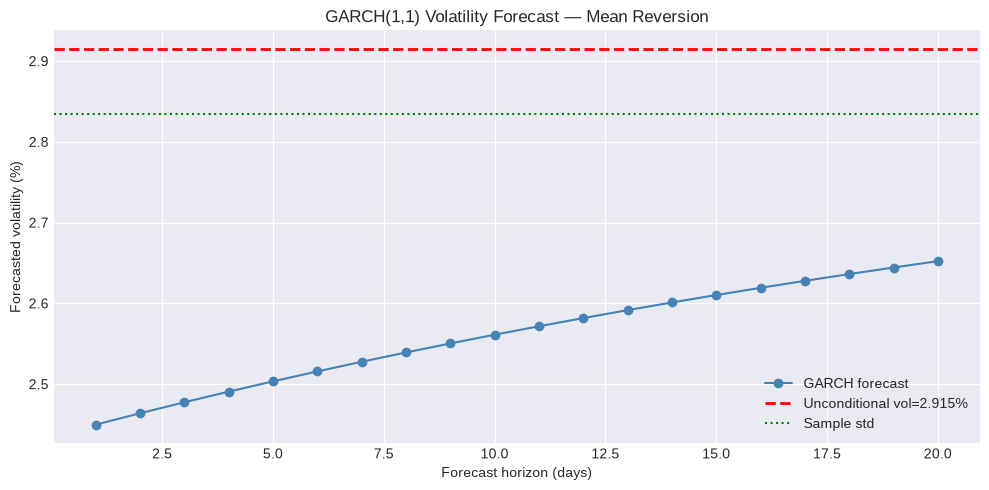

In [15]:
# ── Rolling VaR forecast and backtesting ─────────────────────────────────────
if ARCH_AVAILABLE:
    # Use GARCH(1,1)-t fitted on first 80% of data, roll forward
    n_total  = len(returns)
    n_train  = int(n_total * 0.8)
    conf_lev = 0.99    # 99% VaR

    # Fit on training window
    train_ret = returns.iloc[:n_train]
    model_var = arch_model(train_ret, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    res_var   = model_var.fit(disp='off')

    # Multi-step ahead forecast
    forecasts = res_var.forecast(horizon=20, reindex=False)
    h_vols    = np.sqrt(forecasts.variance.values[-1])
    h_steps   = np.arange(1, 21)

    mu_f  = res_var.params['mu']
    omega = res_var.params['omega']
    a_f   = res_var.params['alpha[1]']
    b_f   = res_var.params['beta[1]']

    unc_vol = np.sqrt(omega / (1 - a_f - b_f))
    print(f"Unconditional (long-run) daily vol: {unc_vol:.4f}%")
    print(f"\n20-day volatility forecast (GARCH mean reversion):")
    for h, v in enumerate(h_vols, 1):
        print(f"  h={h:2d}: sigma_{{t+{h}}} = {v:.4f}%")

    # Plot mean reversion
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(h_steps, h_vols, 'o-', color='steelblue', label='GARCH forecast')
    ax.axhline(unc_vol, color='red', linestyle='--', lw=2, label=f'Unconditional vol={unc_vol:.3f}%')
    ax.axhline(train_ret.std(), color='green', linestyle=':', label='Sample std')
    ax.set_xlabel('Forecast horizon (days)')
    ax.set_ylabel('Forecasted volatility (%)')
    ax.set_title('GARCH(1,1) Volatility Forecast Mean Reversion')
    ax.legend()
    plt.tight_layout()
    plt.show()

99% VaR Backtest (Kupiec Test):
  Expected violations: 1.0% = 20 out of 2000
  Actual violations  : 0.55% = 11
  Kupiec LR stat     : 4.8884
  p-value            : 0.0270
  Verdict: FAIL (miscalibrated)


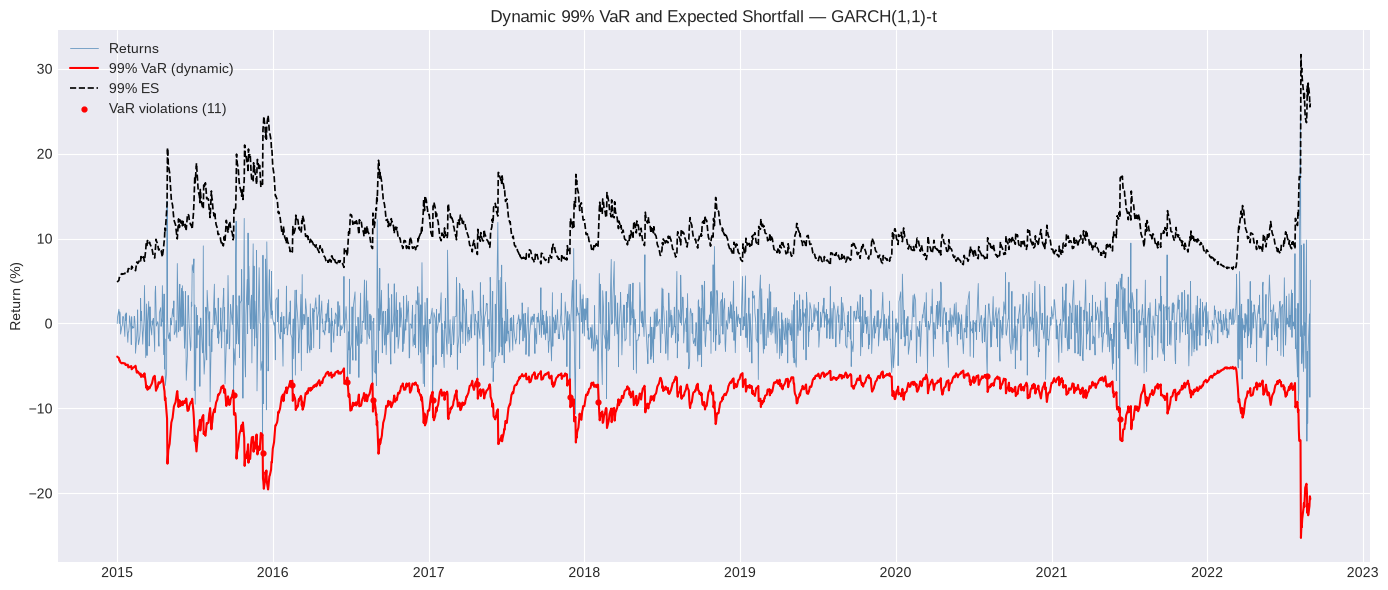

In [16]:
# ── VaR / ES computation and backtesting ────────────────────────────────────
if ARCH_AVAILABLE:
    from scipy.stats import t as t_dist

    # Re-fit on full data for VaR series
    model_full = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    res_full   = model_full.fit(disp='off')

    mu_full    = res_full.params['mu']
    nu_full    = res_full.params['nu']             # Student-t df
    cond_vol   = res_full.conditional_volatility   # sigma_t

    # Student-t quantile for 99% VaR
    alpha_var  = 0.01
    z_alpha    = t_dist.ppf(alpha_var, df=nu_full)  # negative number

    # 1-day VaR: loss exceeds this with probability alpha
    VaR_99     = -(mu_full + z_alpha * cond_vol)    # positive = loss

    # Expected Shortfall
    t_pdf_val  = t_dist.pdf(z_alpha, df=nu_full)
    ES_99      = -(mu_full + cond_vol * t_pdf_val / alpha_var
                   * (nu_full + z_alpha**2) / (nu_full - 1))

    # Kupiec backtest (unconditional coverage)
    actual_rets  = returns.values
    violations   = (actual_rets < -VaR_99.values).astype(int)
    viol_rate    = violations.mean()
    T            = len(violations)
    x            = violations.sum()

    # Kupiec LR statistic
    p_hat = x / T
    if 0 < p_hat < 1:
        lr_uc = -2 * (x * np.log(alpha_var / p_hat) + (T - x) * np.log((1 - alpha_var) / (1 - p_hat)))
        pval_uc = 1 - stats.chi2.cdf(lr_uc, df=1)
    else:
        lr_uc, pval_uc = np.nan, np.nan

    print(f"99% VaR Backtest (Kupiec Test):")
    print(f"  Expected violations: {alpha_var*100:.1f}% = {T*alpha_var:.0f} out of {T}")
    print(f"  Actual violations  : {viol_rate*100:.2f}% = {x}")
    print(f"  Kupiec LR stat     : {lr_uc:.4f}")
    print(f"  p-value            : {pval_uc:.4f}")
    print(f"  Verdict: {'PASS (model is calibrated)' if pval_uc > 0.05 else 'FAIL (miscalibrated)'}")

    # Plot VaR
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(returns.index, actual_rets, lw=0.6, color='steelblue', alpha=0.8, label='Returns')
    ax.plot(returns.index, -VaR_99.values, 'r-', lw=1.5, label='99% VaR (dynamic)')
    ax.plot(returns.index, -ES_99.values, 'k--', lw=1.2, label='99% ES')
    viol_idx = returns.index[violations.astype(bool)]
    ax.scatter(viol_idx, actual_rets[violations.astype(bool)],
               color='red', s=12, zorder=5, label=f'VaR violations ({x})')
    ax.set_title('Dynamic 99% VaR and Expected Shortfall GARCH(1,1)-t')
    ax.set_ylabel('Return (%)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 11. Neural GARCH: Deep Learning for Volatility

Traditional GARCH models impose rigid parametric structure. Neural network approaches relax these assumptions.

### 11.1 LSTM for Volatility Prediction

LSTMs can learn the recursion $\sigma_t^2 = f(\varepsilon_{t-1}^2, \sigma_{t-1}^2, \varepsilon_{t-2}^2, ...)$ without specifying the functional form.

**Architecture:**
- Input: window of past squared returns $[r_{t-k}^2, ..., r_{t-1}^2]$ or standardized returns
- LSTM layers: learn temporal dependencies
- Output: predicted $\sigma_t$ (positivity via softplus or exp activation)

**Hybrid approach (LSTM-GARCH):** Use GARCH-filtered residuals as LSTM input to capture residual dynamics.

### 11.2 N-BEATS for Volatility

N-BEATS (Neural Basis Expansion Analysis) was designed for time series forecasting. Applied to volatility:
- Uses backward and forward residual connections
- Interpretable basis expansion (trend + seasonality stacks)
- Outperforms classical methods on realized volatility datasets (e.g., Oxford-Man RV)

### 11.3 DeepAR with GARCH Innovations

**DeepAR** (Salinas et al., Amazon, 2020) is an autoregressive RNN that models the full predictive distribution:
$$p(z_{i,t} | z_{i,1:t-1}, x_{i,1:T}) = \ell(z_{i,t} | \theta(h_{i,t}))$$

**GARCH enhancement:** Replace the fixed Gaussian likelihood with a GARCH-type heteroskedastic likelihood:
$$z_t \sim \mathcal{N}(\mu_t, \sigma_t^2), \quad \sigma_t^2 = g_{NN}(h_t)$$

This allows DeepAR to capture:
- Long-range dependencies (RNN memory)
- GARCH-type volatility clustering (structured variance head)
- Non-Gaussian tails (distributional choice)

Epoch  10 | Train Loss: 3.545837


Epoch  20 | Train Loss: 3.459966


Epoch  30 | Train Loss: 3.343400

Test RMSE: 2.1474  |  MAE: 1.4020


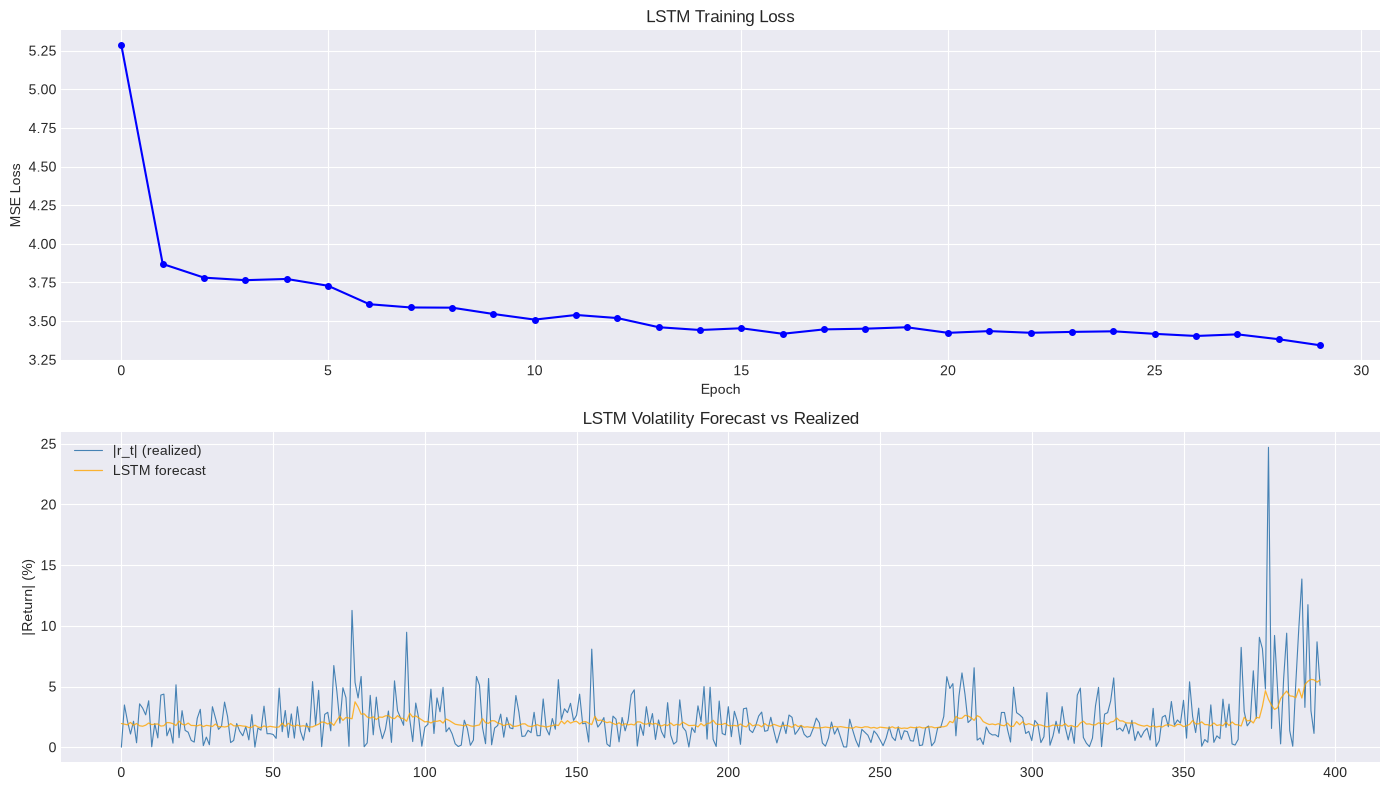

In [17]:
# ── LSTM Volatility Model ──────────────────────────────────────────────────────
if TORCH_AVAILABLE:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    class VolatilityLSTM(nn.Module):
        """LSTM that predicts next-period conditional volatility."""
        def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.1):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                                batch_first=True, dropout=dropout)
            self.head  = nn.Sequential(
                nn.Linear(hidden_size, 32),
                nn.ReLU(),
                nn.Linear(32, 1),
                nn.Softplus()   # guarantees positive output
            )

        def forward(self, x):
            lstm_out, _ = self.lstm(x)           # (batch, seq, hidden)
            last_hidden  = lstm_out[:, -1, :]    # last time step
            return self.head(last_hidden)

    # Prepare data: predict realized vol (proxy: |r_t|) from past 20 returns
    WINDOW = 20
    r_np   = returns.values.astype(np.float32)
    target = np.abs(r_np)   # use |r_t| as proxy for volatility

    X_list, y_list = [], []
    for i in range(WINDOW, len(r_np)):
        X_list.append(r_np[i-WINDOW:i])
        y_list.append(target[i])

    X = torch.tensor(np.array(X_list)).unsqueeze(-1)   # (N, seq, 1)
    y = torch.tensor(np.array(y_list)).unsqueeze(-1)   # (N, 1)

    n_train_nn = int(len(X) * 0.8)
    X_train, X_test = X[:n_train_nn], X[n_train_nn:]
    y_train, y_test = y[:n_train_nn], y[n_train_nn:]

    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

    model_lstm = VolatilityLSTM(hidden_size=64, num_layers=2)
    optimizer  = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
    criterion  = nn.MSELoss()

    losses = []
    for epoch in range(30):
        model_lstm.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model_lstm(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {losses[-1]:.6f}")

    # Evaluate
    model_lstm.eval()
    with torch.no_grad():
        preds_test = model_lstm(X_test).numpy().flatten()

    y_test_np = y_test.numpy().flatten()
    rmse = np.sqrt(np.mean((preds_test - y_test_np)**2))
    mae  = np.mean(np.abs(preds_test - y_test_np))
    print(f"\nTest RMSE: {rmse:.4f}  |  MAE: {mae:.4f}")

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(losses, 'b-o', ms=4)
    axes[0].set_title('LSTM Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')

    idx_test = np.arange(len(preds_test))
    axes[1].plot(idx_test, y_test_np, lw=0.8, label='|r_t| (realized)', color='steelblue')
    axes[1].plot(idx_test, preds_test, lw=0.9, label='LSTM forecast', color='orange', alpha=0.8)
    axes[1].set_title('LSTM Volatility Forecast vs Realized')
    axes[1].set_ylabel('|Return| (%)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("PyTorch not available. Install: pip install torch")

In [18]:
# ── Neural GARCH: LSTM with GARCH-inspired architecture ───────────────────────
if TORCH_AVAILABLE:

    class NeuralGARCH(nn.Module):
        """
        Neural GARCH: combines a learnable GARCH recursion with an LSTM.

        Core idea: sigma2_t = omega + alpha * f_ARCH(eps_{t-1}) + beta * g_GARCH(sigma2_{t-1})
        where f and g are small feed-forward networks.
        """
        def __init__(self, hidden_size=32):
            super().__init__()
            # Learnable ARCH component
            self.arch_net  = nn.Sequential(
                nn.Linear(1, hidden_size), nn.Tanh(),
                nn.Linear(hidden_size, 1), nn.Softplus()
            )
            # Learnable GARCH component
            self.garch_net = nn.Sequential(
                nn.Linear(1, hidden_size), nn.Tanh(),
                nn.Linear(hidden_size, 1), nn.Softplus()
            )
            # Learnable mixing weights
            self.omega = nn.Parameter(torch.tensor([0.0001]))
            self.alpha = nn.Parameter(torch.tensor([0.1]))
            self.beta  = nn.Parameter(torch.tensor([0.8]))

        def forward(self, eps_seq):
            """eps_seq: (batch, seq_len, 1) standardized residuals"""
            B, T, _ = eps_seq.shape
            sigma2 = torch.var(eps_seq, dim=1, keepdim=True).expand(B, T, 1)
            preds  = []

            for t in range(1, T):
                eps_prev   = eps_seq[:, t-1:t, :]
                sigma2_prev = sigma2[:, t-1:t, :]

                arch_term   = self.alpha.abs() * self.arch_net(eps_prev**2)
                garch_term  = self.beta.abs()  * self.garch_net(sigma2_prev)
                new_sigma2  = self.omega.abs() + arch_term + garch_term

                preds.append(new_sigma2)
                sigma2 = torch.cat([sigma2[:, :t, :],
                                    new_sigma2.detach(),
                                    sigma2[:, t+1:, :]], dim=1)

            return torch.cat(preds, dim=1)   # (batch, T-1, 1)

    print("NeuralGARCH architecture defined.")
    model_ng = NeuralGARCH(hidden_size=32)
    total_params = sum(p.numel() for p in model_ng.parameters())
    print(f"Total parameters: {total_params}")
    print(f"\nNeuralGARCH combines the inductive bias of GARCH with neural flexibility.")
    print("In production: pre-train GARCH params as initialization, then fine-tune neural parts.")
    print("Loss: quasi-Gaussian log-likelihood: sum(log(sigma2) + eps2/sigma2)")

NeuralGARCH architecture defined.
Total parameters: 197

NeuralGARCH combines the inductive bias of GARCH with neural flexibility.
In production: pre-train GARCH params as initialization, then fine-tune neural parts.
Loss: quasi-Gaussian log-likelihood: sum(log(sigma2) + eps2/sigma2)


In [19]:
# ── DeepAR with GARCH Innovations ─────────────────────────────────────────────
if TORCH_AVAILABLE:

    class DeepARGARCH(nn.Module):
        """
        Simplified DeepAR with GARCH-type heteroskedastic output distribution.

        Standard DeepAR models: z_t ~ Normal(mu_t, sigma^2) with sigma from RNN.
        GARCH variant:          sigma_t^2 = omega + alpha * eps_{t-1}^2 + beta * sigma_{t-1}^2
                                where (omega, alpha, beta) are outputs of the RNN.
        """
        def __init__(self, input_size=2, hidden_size=64, num_layers=2):
            super().__init__()
            self.rnn = nn.GRU(input_size, hidden_size, num_layers,
                              batch_first=True, dropout=0.1)
            # Mean head
            self.mu_head    = nn.Linear(hidden_size, 1)
            # GARCH parameter heads (positive outputs)
            self.omega_head = nn.Sequential(nn.Linear(hidden_size, 1), nn.Softplus())
            self.alpha_head = nn.Sequential(nn.Linear(hidden_size, 1), nn.Sigmoid())
            self.beta_head  = nn.Sequential(nn.Linear(hidden_size, 1), nn.Sigmoid())

        def forward(self, x):
            """
            x: (batch, seq, 2) [return_t, covariate_t]
            Returns: mu, omega, alpha, beta for each time step
            """
            h, _ = self.rnn(x)
            mu    = self.mu_head(h)
            omega = self.omega_head(h) * 1e-4   # scale down
            alpha = self.alpha_head(h) * 0.2    # keep alpha < 0.2
            beta  = self.beta_head(h)  * 0.8    # keep beta < 0.8
            return mu, omega, alpha, beta

        def garch_variance(self, omega, alpha, beta, eps):
            """Recursively compute GARCH variance from RNN-predicted params."""
            B, T, _ = omega.shape
            sigma2  = torch.ones(B, 1, 1) * eps.var()
            out     = []
            for t in range(T):
                sigma2 = (omega[:, t:t+1, :]
                          + alpha[:, t:t+1, :] * eps[:, t:t+1, :]**2
                          + beta[:, t:t+1, :]  * sigma2)
                out.append(sigma2)
            return torch.cat(out, dim=1)

    model_deepar = DeepARGARCH(input_size=2, hidden_size=64)
    total_params_dar = sum(p.numel() for p in model_deepar.parameters())
    print("DeepAR-GARCH architecture:")
    print(model_deepar)
    print(f"\nTotal parameters: {total_params_dar}")
    print("\nTraining objective: maximize Gaussian log-likelihood with GARCH variance:")
    print("  L = -0.5 * sum(log(sigma2_t) + (r_t - mu_t)^2 / sigma2_t)")

DeepAR-GARCH architecture:
DeepARGARCH(
  (rnn): GRU(2, 64, num_layers=2, batch_first=True, dropout=0.1)
  (mu_head): Linear(in_features=64, out_features=1, bias=True)
  (omega_head): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
    (1): Softplus(beta=1.0, threshold=20.0)
  )
  (alpha_head): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (beta_head): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Total parameters: 38276

Training objective: maximize Gaussian log-likelihood with GARCH variance:
  L = -0.5 * sum(log(sigma2_t) + (r_t - mu_t)^2 / sigma2_t)


## 12. Production Patterns: Model Selection, Diagnostics, Pipeline

### Model Selection Protocol

1. **Test for ARCH effects** (Ljung-Box on $\varepsilon_t^2$, ARCH-LM)
2. **Start with GARCH(1,1)-t** outperforms in most practical cases
3. **Test for asymmetry** compare AIC of GARCH vs GJR vs EGARCH
4. **Test for long memory** run KPSS or GPH test on $\log|r_t|$
5. **Validate error distribution** QQ plot of standardized residuals
6. **Backtest VaR** Kupiec and Christoffersen tests

### Diagnostic Tests for Fitted GARCH

| Test | H₀ | Tool |
|---|---|---|
| Ljung-Box on $\hat{z}_t$ | No autocorrelation in standardized residuals | `acorr_ljungbox(z, lags=[5,10])` |
| Ljung-Box on $\hat{z}_t^2$ | No autocorrelation in squared standardized residuals | `acorr_ljungbox(z**2, lags=[5,10])` |
| ARCH-LM on $\hat{z}_t$ | No remaining ARCH effects | `het_arch(z)` |
| Jarque-Bera on $\hat{z}_t$ | Normality | `stats.jarque_bera(z)` |
| Kupiec test | Correct VaR coverage | Manual LR test |

In [20]:
# ── Production GARCH pipeline ─────────────────────────────────────────────────
if ARCH_AVAILABLE:

    def fit_and_diagnose_garch(returns_series, model_spec='GARCH', p=1, o=0, q=1, dist='t'):
        """
        Fit a GARCH-type model and run full diagnostic suite.
        """
        print(f"\n{'='*60}")
        print(f"Model: {model_spec}(p={p}, o={o}, q={q}), dist={dist}")
        print('='*60)

        # 1. Fit
        m    = arch_model(returns_series, mean='Constant', vol=model_spec,
                          p=p, o=o, q=q, dist=dist)
        res  = m.fit(disp='off')

        # 2. Standardized residuals
        z = (res.resid / res.conditional_volatility).dropna()

        # 3. Diagnostics
        lb_z   = acorr_ljungbox(z,    lags=[10], return_df=True)
        lb_z2  = acorr_ljungbox(z**2, lags=[10], return_df=True)
        arch_s, arch_p, _, _ = het_arch(z.values, nlags=10)
        jb_s, jb_p           = stats.jarque_bera(z.values)

        print(f"  AIC: {res.aic:.2f}  |  BIC: {res.bic:.2f}")
        print(f"  Params: {dict(zip(res.params.index, res.params.values.round(6)))}")
        print(f"\n  --- Residual Diagnostics ---")
        print(f"  LB-Q(10) on z:    stat={lb_z['lb_stat'].iloc[0]:.3f}, p={lb_z['lb_pvalue'].iloc[0]:.4f}")
        print(f"  LB-Q(10) on z²:   stat={lb_z2['lb_stat'].iloc[0]:.3f}, p={lb_z2['lb_pvalue'].iloc[0]:.4f}")
        print(f"  ARCH-LM(10):      stat={arch_s:.3f}, p={arch_p:.4f}")
        print(f"  Jarque-Bera:      stat={jb_s:.3f}, p={jb_p:.4f}")
        print(f"  Std resid std:    {z.std():.4f} (should be ~1.0)")
        print(f"  Std resid kurt:   {z.kurtosis():.4f} (excess; Normal=0)")

        verdict = []
        if lb_z['lb_pvalue'].iloc[0] > 0.05:  verdict.append('mean: OK')
        else:                                  verdict.append('mean: FAIL')
        if lb_z2['lb_pvalue'].iloc[0] > 0.05: verdict.append('variance: OK')
        else:                                  verdict.append('variance: FAIL')
        print(f"\n  Verdict: {', '.join(verdict)}")

        return res

    # Run the diagnostic pipeline on multiple models
    for spec, params in [('GARCH', (1, 0, 1)), ('GARCH', (1, 1, 1)), ('EGARCH', (1, 0, 1))]:
        p, o, q = params
        fit_and_diagnose_garch(returns, model_spec=spec, p=p, o=o, q=q, dist='t')


Model: GARCH(p=1, o=0, q=1), dist=t
  AIC: 9574.38  |  BIC: 9602.38
  Params: {'mu': np.float64(-0.008386), 'omega': np.float64(0.235466), 'alpha[1]': np.float64(0.086059), 'beta[1]': np.float64(0.888904), 'nu': np.float64(7.144094)}

  --- Residual Diagnostics ---
  LB-Q(10) on z:    stat=7.611, p=0.6668
  LB-Q(10) on z²:   stat=10.724, p=0.3794
  ARCH-LM(10):      stat=10.373, p=0.4084
  Jarque-Bera:      stat=129.369, p=0.0000
  Std resid std:    0.9954 (should be ~1.0)
  Std resid kurt:   1.2515 (excess; Normal=0)

  Verdict: mean: OK, variance: OK

Model: GARCH(p=1, o=1, q=1), dist=t
  AIC: 9576.16  |  BIC: 9609.77
  Params: {'mu': np.float64(-0.013241), 'omega': np.float64(0.232014), 'alpha[1]': np.float64(0.079617), 'gamma[1]': np.float64(0.011076), 'beta[1]': np.float64(0.890123), 'nu': np.float64(7.166583)}

  --- Residual Diagnostics ---
  LB-Q(10) on z:    stat=7.665, p=0.6615
  LB-Q(10) on z²:   stat=10.738, p=0.3783
  ARCH-LM(10):      stat=10.402, p=0.4059
  Jarque-Bera:

Volatility Term Structure (GARCH(1,1)-t forecast):
Horizon      Daily Vol    Ann. Vol    
------------------------------------
  1d         6.7253       106.7609    %
  1w         6.4633       102.6018    %
  2w         6.1579       97.7538     %
  1m         5.5659       88.3559     %
  3m         4.1039       65.1476     %
  6m         3.3030       52.4337     %
  1y         3.0767       48.8412     %


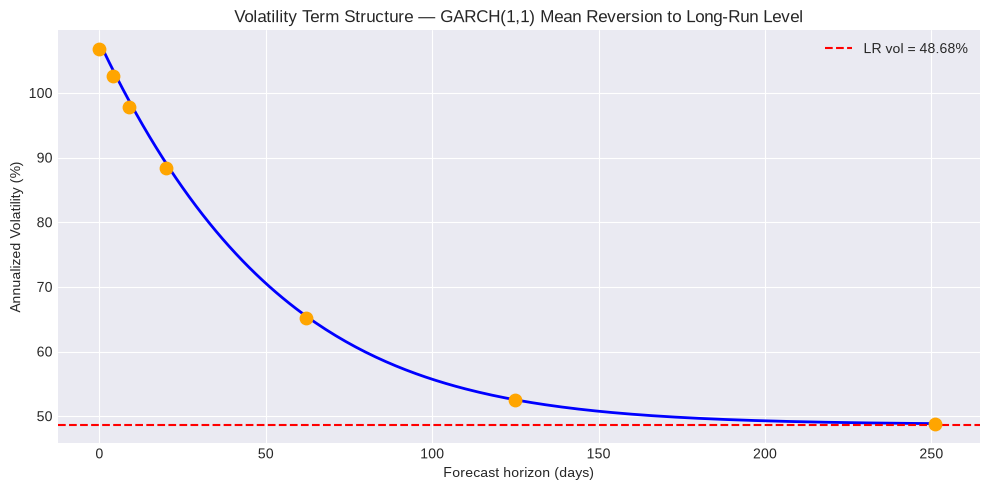

In [21]:
# ── Annualized volatility surface and term structure ─────────────────────────
if ARCH_AVAILABLE:

    # Re-use best GARCH(1,1)-t model on S&P 500
    model_final = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    res_final   = model_final.fit(disp='off')

    # Multi-horizon forecast
    horizons = [1, 5, 10, 21, 63, 126, 252]  # 1d, 1w, 2w, 1m, 3m, 6m, 1y
    forecasts_all = res_final.forecast(horizon=252, reindex=False)
    var_forecasts  = forecasts_all.variance.values[-1]   # variance term structure

    # Annualized volatility term structure
    ann_vol_ts = [np.sqrt(var_forecasts[h-1] * 252) for h in horizons]

    print("Volatility Term Structure (GARCH(1,1)-t forecast):")
    print(f"{'Horizon':<12} {'Daily Vol':<12} {'Ann. Vol':<12}")
    print("-" * 36)
    for h, av in zip(horizons, ann_vol_ts):
        daily_v = np.sqrt(var_forecasts[h-1])
        label = {1:'1d', 5:'1w', 10:'2w', 21:'1m', 63:'3m', 126:'6m', 252:'1y'}[h]
        print(f"  {label:<10} {daily_v:<12.4f} {av:<12.4f}%")

    # Plot term structure
    fig, ax = plt.subplots(figsize=(10, 5))
    all_ann_vol = np.sqrt(var_forecasts * 252)
    ax.plot(np.arange(1, 253), all_ann_vol, 'b-', lw=2)
    unc_ann_vol = np.sqrt(res_final.params['omega'] /
                          (1 - res_final.params['alpha[1]'] - res_final.params['beta[1]']) * 252)
    ax.axhline(unc_ann_vol, color='red', linestyle='--', label=f'LR vol = {unc_ann_vol:.2f}%')
    ax.scatter([h-1 for h in horizons], ann_vol_ts, color='orange', s=80, zorder=5)
    ax.set_xlabel('Forecast horizon (days)')
    ax.set_ylabel('Annualized Volatility (%)')
    ax.set_title('Volatility Term Structure GARCH(1,1) Mean Reversion to Long-Run Level')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Additional Learning Resources

### Foundational Papers

1. **Engle, R.F. (1982)** "Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation" *Econometrica 50(4):987-1007* The original ARCH paper (Nobel Prize basis). https://doi.org/10.2307/1912773

2. **Bollerslev, T. (1986)** "Generalized Autoregressive Conditional Heteroskedasticity" *Journal of Econometrics 31:307-327* The GARCH generalization. https://doi.org/10.1016/0304-4076(86)90063-1

3. **Nelson, D.B. (1991)** "Conditional Heteroskedasticity in Asset Returns: A New Approach" *Econometrica 59(2):347-370* EGARCH model. https://doi.org/10.2307/2938260

4. **Glosten, L.R., Jagannathan, R. & Runkle, D.E. (1993)** "On the Relation between the Expected Value and the Volatility of the Nominal Excess Return on Stocks" *Journal of Finance 48(5):1779-1801* GJR-GARCH.

5. **Engle, R.F. (2002)** "Dynamic Conditional Correlation: A Simple Class of Multivariate GARCH Models" *Journal of Business & Economic Statistics 20(3):339-350* DCC-GARCH. https://doi.org/10.1198/073500102288618487

6. **Baillie, R.T., Bollerslev, T. & Mikkelsen, H.O. (1996)** "Fractionally Integrated Generalized Autoregressive Conditional Heteroskedasticity" *Journal of Econometrics 74:3-30* FIGARCH.

7. **Ding, Z., Granger, C.W.J. & Engle, R.F. (1993)** "A long memory property of stock market returns and a new model" *Journal of Empirical Finance 1:83-106* APARCH model.

### Software Documentation

8. **arch Python library** Kevin Sheppard's comprehensive ARCH/GARCH implementation: https://arch.readthedocs.io/en/latest/

9. **statsmodels TARCH/ARCH** https://www.statsmodels.org/stable/tsa.html

10. **rugarch (R)** The most feature-complete GARCH package: https://cran.r-project.org/package=rugarch

### Online Courses and Lectures

11. **QuantLib Python** Volatility surface construction: https://quantlib-python-docs.readthedocs.io/

12. **NYU Stern Volatility and Financial Risk** (Engle's own course): https://stern.nyu.edu/volatility

13. **Tim Bollerslev's lecture notes** on GARCH models: https://econ.duke.edu/people/tim-bollerslev

14. **Oxford-Man Realized Library** Empirical realized volatility data: https://realized.oxford-man.ox.ac.uk/

15. **Kevin Sheppard's Financial Econometrics Notes** (Python-based): https://www.kevinsheppard.com/teaching/mfe/notes/

### Deep Learning for Volatility

16. **Luo, J., Klein, T. & Ji, Q. (2019)** "Forecasting Realized Volatility of Crude Oil Futures with LSTM" *Resources Policy*

17. **Salinas, D., Flunkert, V., Gasthaus, J. & Januschowski, T. (2020)** "DeepAR: Probabilistic Forecasting with Autoregressive Recurrent Networks" *International Journal of Forecasting* https://arxiv.org/abs/1704.04110

18. **Oreshkin, B.N., Carpov, D., Chapados, N. & Bengio, Y. (2020)** "N-BEATS: Neural Basis Expansion Analysis for Interpretable Time Series Forecasting" *ICLR 2020* https://arxiv.org/abs/1905.10437

### Datasets

19. **Yahoo Finance via yfinance**: `pip install yfinance; import yfinance as yf; df = yf.download('^GSPC', start='2000-01-01')`

20. **CRSP** Comprehensive stock/return database (subscription): https://www.crsp.org/

21. **FRED (Federal Reserve)** Volatility indices (VIX etc.): https://fred.stlouisfed.org/series/VIXCLS